----

<div style="border: 2px solid black; padding: 30px; margin: 20px auto; max-width: 800px;">

<p align="center">
  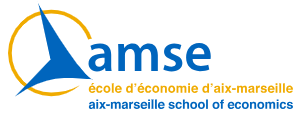
  &nbsp;&nbsp;&nbsp;&nbsp;
  <b style="font-size:1.5em">Aix-Marseille School of Economics</b>
  &nbsp;&nbsp;&nbsp;&nbsp;
  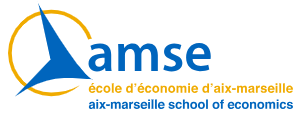
</p>

<p align="center"><strong>Magistere in Economics, Data Science, and Finance</strong></p>

---

<p align="center"><big><strong>📊 Exploratory Data Analysis (EDA) Project 📈: Student Performance in Portugal </strong></big></p>

---

<p style="text-align:left;">
  <strong> 👥 Written by: </strong><br>
  <strong>SEKONGO Zodigui Mamadou </strong><br>
  <br>
  <strong>📚 Course:</strong> Programming for Data Science <br>
  <strong>Academic Year:</strong> 2025-2026
</p>

---

<p align="center">
  <strong> 👨‍🏫 Supervisor:</strong> Jean Delpech <br>
  <em>May 2026</em>
</p>
</div>

---

## **1. Introduction**

<p style="text-align: justify;">

Academic achievement is one of the central concerns of modern education systems.While cognitive ability plays an undeniable role, a substantial body of  research  in educational sociology highlights the influence of non-academic factors family environment lifestyle habits, social behaviours, and material learning conditions. Understanding how these dimensions interact with academic outcomes is critical for teachers, schools, and policymakers alike. This project conducts an Exploratory Data Analysis (EDA) on data collected from two Portuguese secondary schools, aiming to identify and quantify the influence of behavioural, familial, and personal variables on student performance in Mathematics and Portuguese, using descriptive statistics, hypothesis testing, and multiple linear regression.



## **2. Context**

### **2.1 Data Source**

The dataset originates from the UCI Machine Learning Repository (Cortez & Silva,2008) and covers students from two Portuguese schools: Gabriel Pereira (GP) and Mousinho da Silveira (MS). It consists of two separate files **student-mat.csv** (395 students, Mathematics) and **student-por.csv** (649 students, Portuguese) each containing 33 variables spanning demographic, family, behavioural, and academic dimensions.Notably, 382 students appear in both datasets, enabling cross-subject comparisons.

### **2.2 Relevance**

Studying academic performance through non-academic lenses is well-grounded in the literature from Bourdieu's cultural capital theory to OECD PISA findings all pointing to the significant role of social origin and parental education on student trajectories. In the Portuguese context, where dropout rates and performance inequalities have long been a policy concern, identifying actionable levers (reducing absences, encouraging study time, addressing alcohol consumption) can help design more targeted and effective educational support programmes.


## **3. Research Question**

> *"To what extent do factors such as study time, past failures, absences, alcohol
> consumption, and mother's education level explain students' final grades in
> Mathematics and Portuguese?"*

G1 and G2 are deliberately excluded from the regression models: although highly
correlated with G3 (r > 0.90), including them would mechanically inflate R² while
obscuring the true effect of the behavioural and family factors we seek to measure.
We therefore favour a more interpretable model over a purely predictive one.

Three sub-questions guide the analysis:
- Is there a significant performance difference between Mathematics and Portuguese?
- Are the relationships between the selected factors and final grades similar across
  subjects, or subject-specific?
- Which variable exerts the strongest influence on the final grade, all else equal?

These are addressed through a progressive analytical pipeline: descriptive
statistics, exploratory visualisations, hypothesis testing (Mann-Whitney, Chi²,
Pearson/Spearman correlation), and separate multiple OLS regressions for each
subject, followed by a comparative synthesis.

</p>

# **A) EDA Section**

# **Outlines**
> 1. **Dataset Information**
> 2. **Importing Essential Libraries and Loading the Data**
>> 2.1. Importing Essential Libraries
>>
>> 2.2. Loading the Data
> 3. **Data Understanding**
>> 3.1. Data Structure
>>
>> 3.2. Data Quality
> 4. **Data Preparation**
>> 4.1. Data Cleaning
>>
>> 4.2. Variable Encoding
> 5. **Bivariate Analysis & Tests**
>> 5.1 Numerical Variables vs Pass/Fail
>>
>> 5.2 Categorical Variables vs Pass/Fail

>>
> 6. **Correlation Analysis**
> 7. **Multicollinearity Analysis**
>> 7.1. VIF Analysis
>>
>> 7.2. Linear Regression
>>
>>7.3 Commentary
> 8. **Conclusion & Recommendations**
>> 8.1 Summary of Key Findings
>> 
>> 8.2 General Conclusion
>> 
>> 8.3 Educational Recommendations
>> 
>> 8.4 Limitations
>> 
>> 8.5 Perspectives



# **B) Dashboard Section (Bonus)**

----------------

## **1) DataSet Information** 

<p style="text-align: justify;">
This data approach student achievement in secondary education of two Portuguese schools. The data attributes include student grades, demographic, social and school related features and it was collected by using school reports and questionnaires. 
<p style="text-align: justify;">
The dataset originates from the <strong>UCI Machine Learning Repository</strong> (Cortez &amp; Silva, 2008)
and covers students from two Portuguese schools: Gabriel Pereira (GP) and Mousinho da Silveira (MS).
It consists of two separate files:
</p>

- **student-mat.csv** — 395 students, Mathematics
- **student-por.csv** — 649 students, Portuguese language

Each file contains **33 variables** spanning demographic, family, behavioural, and academic dimensions. Notably, 382 students appear in both datasets, enabling cross-subject comparisons.

**Important note**: the target attribute G3 has a strong correlation with attributes G2 and G1. This occurs because G3 is the final year grade (issued at the 3rd period), while G1 and G2 correspond to the 1st and 2nd period grades. It is more difficult to predict G3 without G2 and G1, but such prediction is much more useful.

</p>



## **2) Importing essential libraries and loading the data**

### 2.1) Importing essential libraries


In [50]:
## import libraries
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
#for use ANOVA and Fine-tuning using random Search
from scipy import stats 
# to clear RAM
import gc

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
# Preprocessing allows us to standarsize our data
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, MinMaxScaler
# Allows us to split our data into training and testing data and evaluate data on k-fold
from sklearn.model_selection import cross_val_score, train_test_split
# Import PCA Transformation
from sklearn.decomposition import PCA
# from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
# evaluate Linear regression model
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import mannwhitneyu
import warnings
import math
import matplotlib.patches as mpatches
from scipy.stats import mannwhitneyu, chi2_contingency
warnings.filterwarnings('ignore')

### **2.2) Loading the data**

<p style="text-align: justify;">
After importing the necessary libraries, we download the data from our Drive. At this stage, the two datasets are retrieved and will later be merged into a single dataset for our analysis.
<p>

In [51]:
# create data folder
os.makedirs("data", exist_ok=True)

url_mat = "https://drive.google.com/uc?id=1FelG_t8W2BqRlPzOzgolLCqsWKCvzy8f"
url_por = "https://drive.google.com/uc?id=1jVE4cOz_92EJXQdsedir7lxbSD81wzKj"

mat = pd.read_csv(url_mat, sep=";")
por = pd.read_csv(url_por, sep=";")

mat.to_csv("data/student_mat.csv", index=False)
por.to_csv("data/student_por.csv", index=False)

print("Ok , datasets saved in data folder")

Ok , datasets saved in data folder


In [52]:
# create dataframe
df = pd.concat([mat, por], axis=0)

In [53]:
# save locally
df.to_csv("data/student_performance.csv", index=False)

# **3 Data Understanding** 

### 3.1 **Data Structure**
<p style="text-align: justify;">
This section examines the overall structure of the dataset. First, we identify the different types of variables present in the data (numerical and categorical variables). Then, we compute simple descriptive statistics to summarize the main characteristics of the dataset, such as the mean, standard deviation, and distribution of values. Finally, we analyze the correlation matrix to explore the relationships between numerical variables and identify potential dependencies among them.
<p>

### a) **Variable names cheking**

In [54]:
# Display the first few rows of the dataset
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [55]:
# Check Name of Columns
print("Columns in the dataset:")
print(df.columns)

Columns in the dataset:
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


It can be observed that the variable names are not presented in a standardized format, which may reduce readability. Adopting a consistent naming convention would improve clarity and facilitate data analysis.

We have some numeric columns that are `Not Countable`.  
We have some numeric columns that are encoded version of a `Categorical Variable`.

The columns already are in the best way to express with respect to thier name.

### b) **Small description of dataset**

In [56]:
# Describe the dataset
print("Statistical summary of the dataset:")
print(round(df.describe(), 2))

Statistical summary of the dataset:
           age     Medu     Fedu  traveltime  studytime  failures   famrel  \
count  1044.00  1044.00  1044.00     1044.00    1044.00   1044.00  1044.00   
mean     16.73     2.60     2.39        1.52       1.97      0.26     3.94   
std       1.24     1.12     1.10        0.73       0.83      0.66     0.93   
min      15.00     0.00     0.00        1.00       1.00      0.00     1.00   
25%      16.00     2.00     1.00        1.00       1.00      0.00     4.00   
50%      17.00     3.00     2.00        1.00       2.00      0.00     4.00   
75%      18.00     4.00     3.00        2.00       2.00      0.00     5.00   
max      22.00     4.00     4.00        4.00       4.00      3.00     5.00   

       freetime    goout     Dalc     Walc   health  absences       G1  \
count   1044.00  1044.00  1044.00  1044.00  1044.00   1044.00  1044.00   
mean       3.20     3.16     1.49     2.28     3.54      4.43    11.21   
std        1.03     1.15     0.91     1

In [57]:
# Number of numrcal variables
num_numerical = df.select_dtypes(include=[np.number]).shape[1]
print(f"Number of numerical variables: {num_numerical}")
# Number of categorical variables
num_categorical = df.select_dtypes(include=['object']).shape[1]
print(f"Number of categorical variables: {num_categorical}")

# Data types deéscription
print("\nData types of each column:")
print(df.info())

Number of numerical variables: 16
Number of categorical variables: 17

Data types of each column:
<class 'pandas.core.frame.DataFrame'>
Index: 1044 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      1044 non-null   object
 1   sex         1044 non-null   object
 2   age         1044 non-null   int64 
 3   address     1044 non-null   object
 4   famsize     1044 non-null   object
 5   Pstatus     1044 non-null   object
 6   Medu        1044 non-null   int64 
 7   Fedu        1044 non-null   int64 
 8   Mjob        1044 non-null   object
 9   Fjob        1044 non-null   object
 10  reason      1044 non-null   object
 11  guardian    1044 non-null   object
 12  traveltime  1044 non-null   int64 
 13  studytime   1044 non-null   int64 
 14  failures    1044 non-null   int64 
 15  schoolsup   1044 non-null   object
 16  famsup      1044 non-null   object
 17  paid        1044 non-null   object
 

At this stage, we observe that our dataset includes 1,044 individuals – likely students – and a total of 33 variables, of which 16 are numerical and 17 are categorical.

<span style="color:red">NB:</span> It is important to distinguish, among numerical variables, those that are discrete from those that are continuous, as they may require different analytical treatments. However, in this dataset, numerical variables generally correspond either to counts or ordered categories, and therefore many of them can be considered as discrete rather than truly continuous variables.

-----

Based on dataset information we know that `G1`,`G2`,`G3` are highly correlated therefore for simplicity we only use check releation between features and `G3`

In [58]:
# Covariance matrix for G1, G2, and G3
cov_matrix = df[["G1", "G2", "G3"]].cov()
print("Covariance matrix for G1, G2, and G3:")
print(round(cov_matrix, 2))

Covariance matrix for G1, G2, and G3:
      G1     G2     G3
G1  8.90   8.42   9.33
G2  8.42  10.79  11.56
G3  9.33  11.56  14.94


In [59]:
# Correlation matrix for G1, G2, G3
corr_matrix = df[["G1", "G2", "G3"]].corr()
print("Correlation matrix for G1, G2, and G3:")
print(corr_matrix)

Correlation matrix for G1, G2, and G3:
          G1        G2        G3
G1  1.000000  0.858739  0.809142
G2  0.858739  1.000000  0.910743
G3  0.809142  0.910743  1.000000


The correlation analysis shows that G1, G2, and G3 are strongly correlated. This result is consistent with expectations, as G3 is computed based on G1 and G2, according to the dataset description.

### 3.2 **Data Quality**

<p style="text-align: justify;">
In this section, we assess the overall quality of the dataset. We first examine the presence of missing values to determine whether some information is incomplete. Then, we check for potential inconsistencies in the data, such as invalid or unexpected values. Finally, we analyze the overall distributions of the variables to detect possible outliers and better understand the general patterns present in the dataset.

#### a) **Check for spaces in variables names**


In [60]:
# Check for spaces in column names, if there are any, print them out
print("Columns with spaces in their names:")
for col in df.columns:
    if " " in col:
        print(f"- '{col}'")
    else:
        print(f"- '{col}' (no spaces)")

Columns with spaces in their names:
- 'school' (no spaces)
- 'sex' (no spaces)
- 'age' (no spaces)
- 'address' (no spaces)
- 'famsize' (no spaces)
- 'Pstatus' (no spaces)
- 'Medu' (no spaces)
- 'Fedu' (no spaces)
- 'Mjob' (no spaces)
- 'Fjob' (no spaces)
- 'reason' (no spaces)
- 'guardian' (no spaces)
- 'traveltime' (no spaces)
- 'studytime' (no spaces)
- 'failures' (no spaces)
- 'schoolsup' (no spaces)
- 'famsup' (no spaces)
- 'paid' (no spaces)
- 'activities' (no spaces)
- 'nursery' (no spaces)
- 'higher' (no spaces)
- 'internet' (no spaces)
- 'romantic' (no spaces)
- 'famrel' (no spaces)
- 'freetime' (no spaces)
- 'goout' (no spaces)
- 'Dalc' (no spaces)
- 'Walc' (no spaces)
- 'health' (no spaces)
- 'absences' (no spaces)
- 'G1' (no spaces)
- 'G2' (no spaces)
- 'G3' (no spaces)


#### b) **Missing values, Check null and redundant values**

In [61]:
# Missing values in each column
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


We can see that there are no missing values in the dataset, which is a good sign for our analysis.


In [62]:
# Check null and redundant values
print("Number of duplicate rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Number of duplicate rows after dropping duplicates:", df.duplicated().sum())

Number of duplicate rows: 0
Number of duplicate rows after dropping duplicates: 0


The dataset does not contain any duplicate rows. After checking for duplicates and removing them if necessary, the number of duplicate rows remains zero, indicating that all observations in the dataset are unique.

In [63]:
# Check if the index is unique
print("Is the index unique?", df.index.is_unique)

Is the index unique? False


<p style="text-align: justify;">
The result False indicates that the DataFrame index is not unique, meaning that some rows share the same index value. This is due to the union operation performed at the beginning to consolidate the final dataset. Therefore, it is not an error in our dataset.

In [64]:
# Check for null value
print("Number of null values in each column:")
print(df.isnull().sum())

Number of null values in each column:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [65]:
# checkingg for duplicated values
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [66]:
# Verify if stidy time is <= 0
print("Number of rows with study time <= 0:", (df["studytime"] <= 0).sum())

Number of rows with study time <= 0: 0


We do not have any `duplicate` and `null` values.

#### d) **Ouliers Values**

In this section, we aim to identify potential outliers in our continuous variables, so that they can be addressed later if necessary.


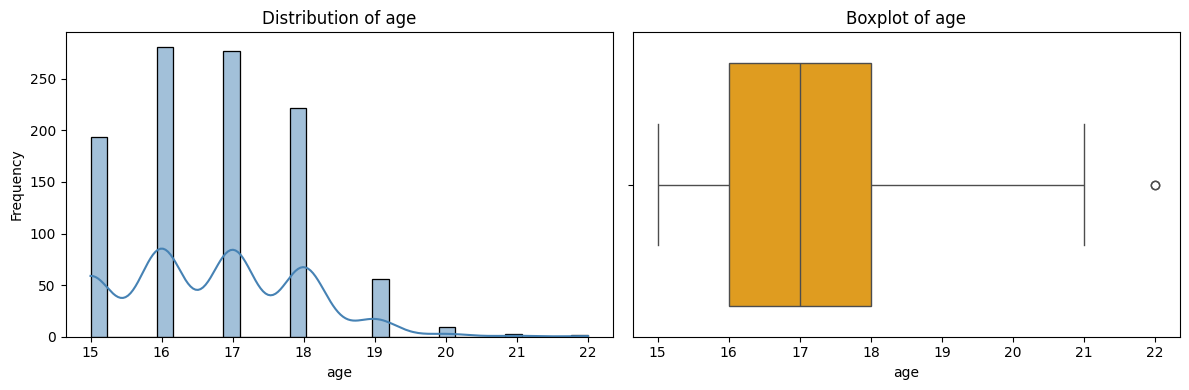

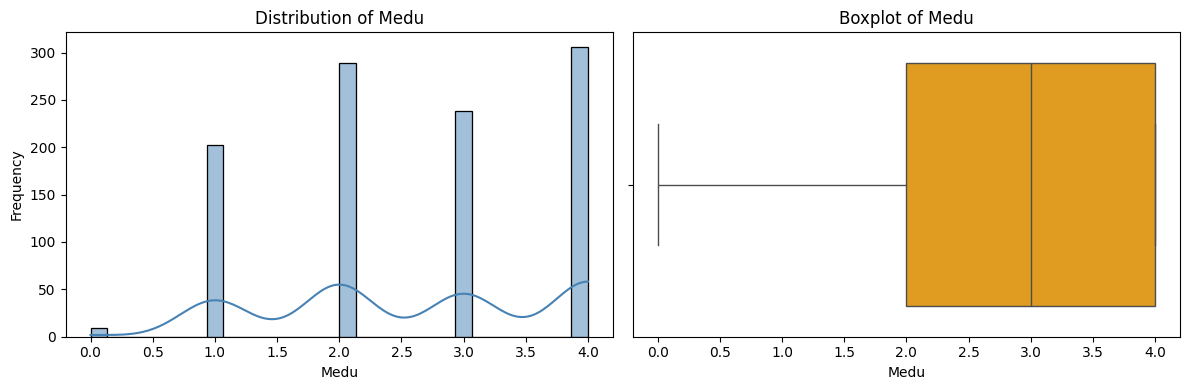

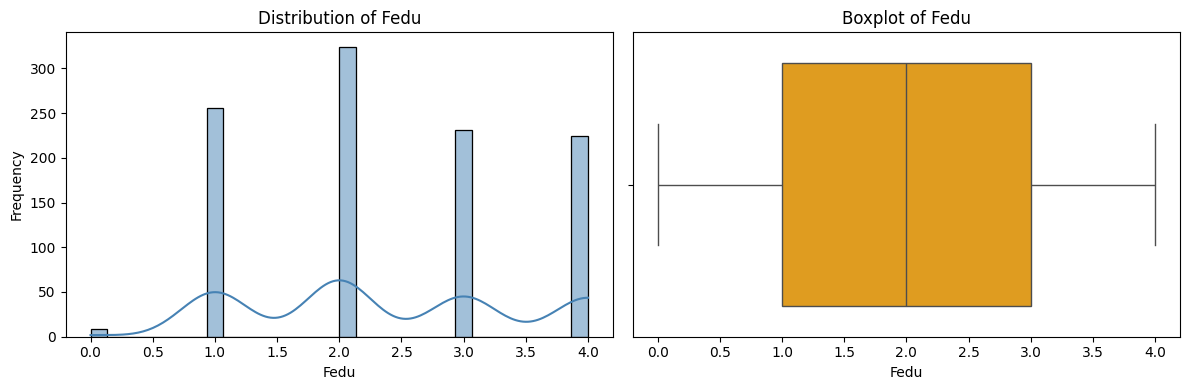

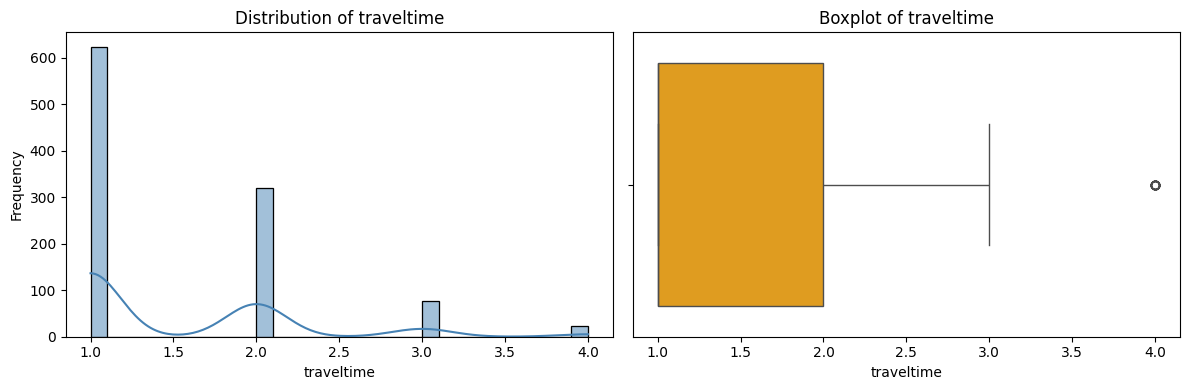

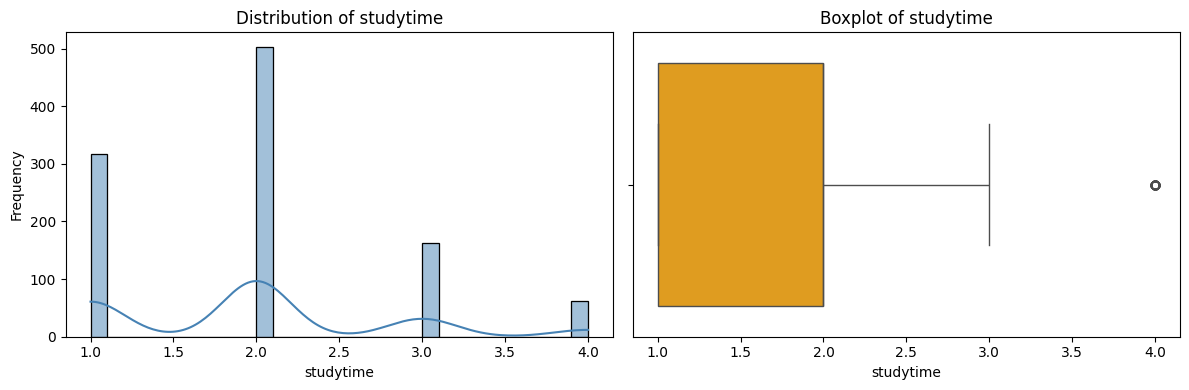

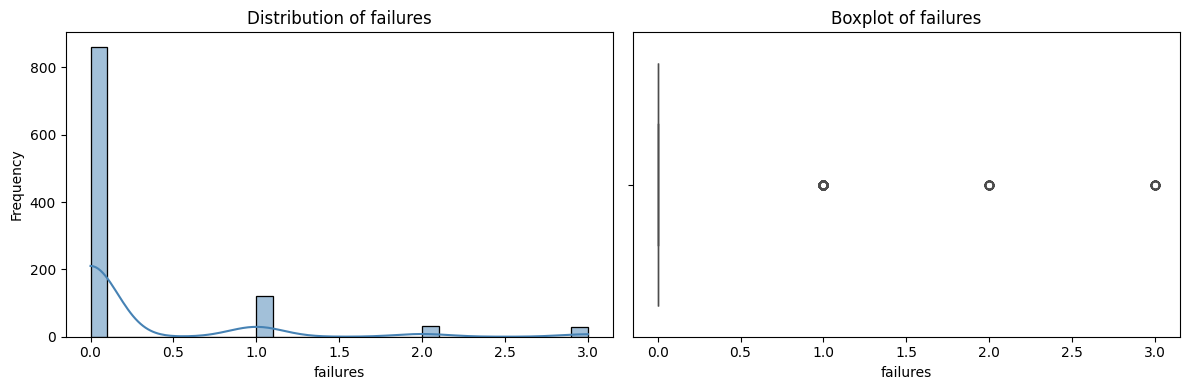

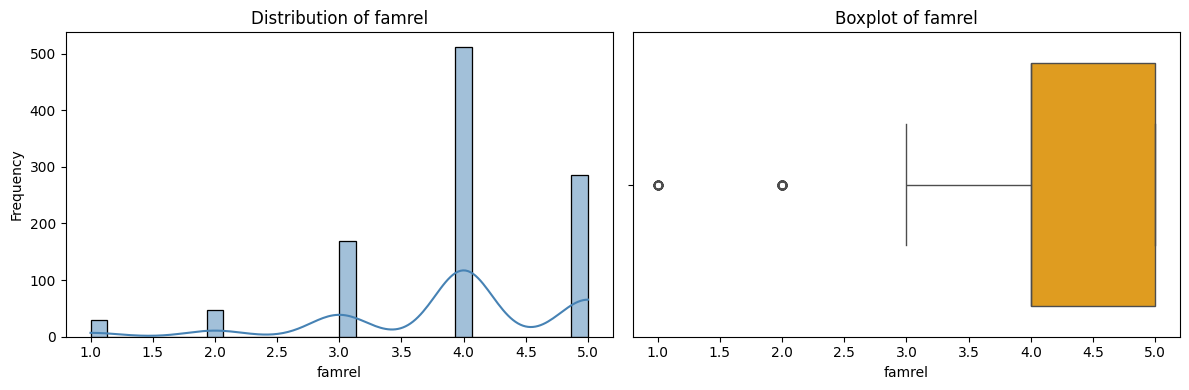

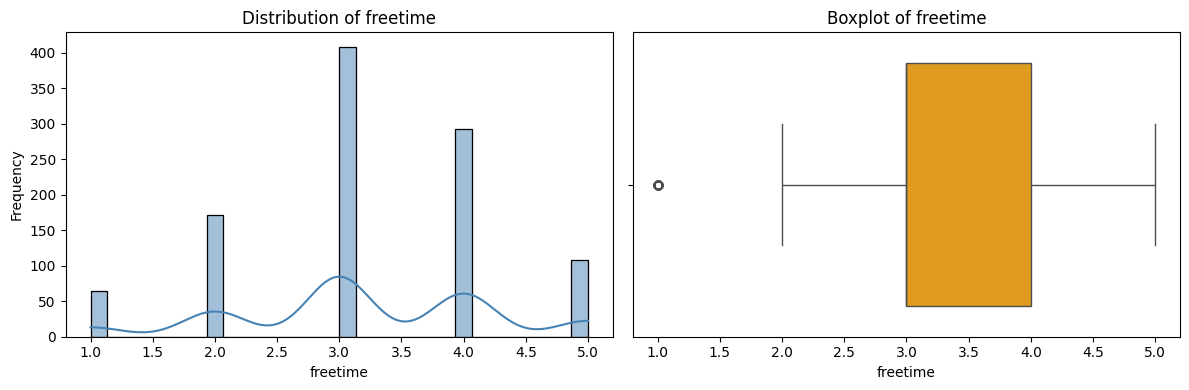

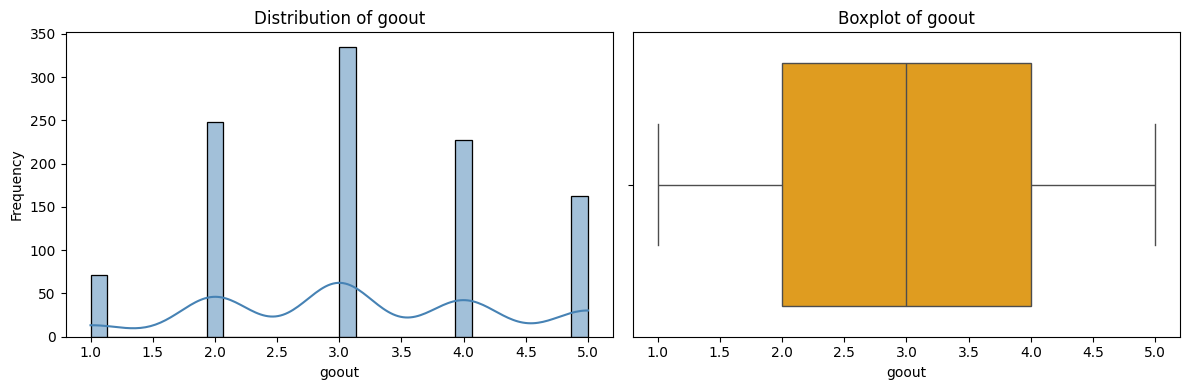

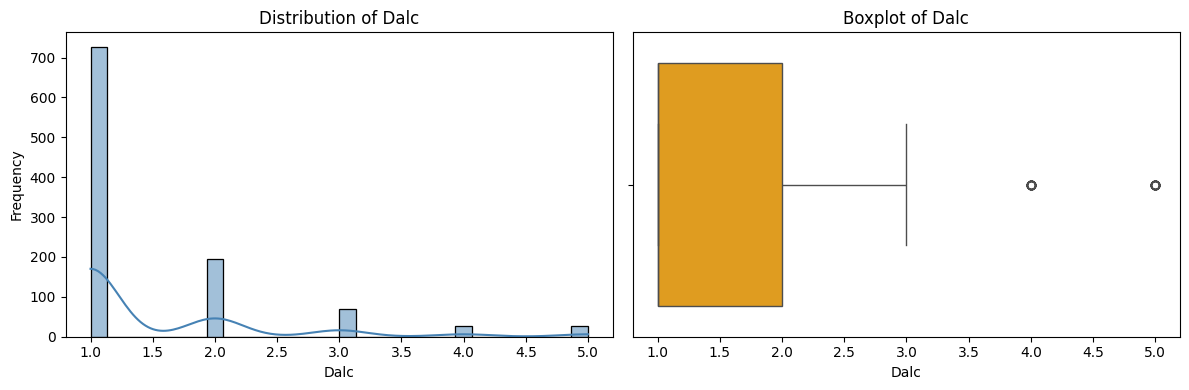

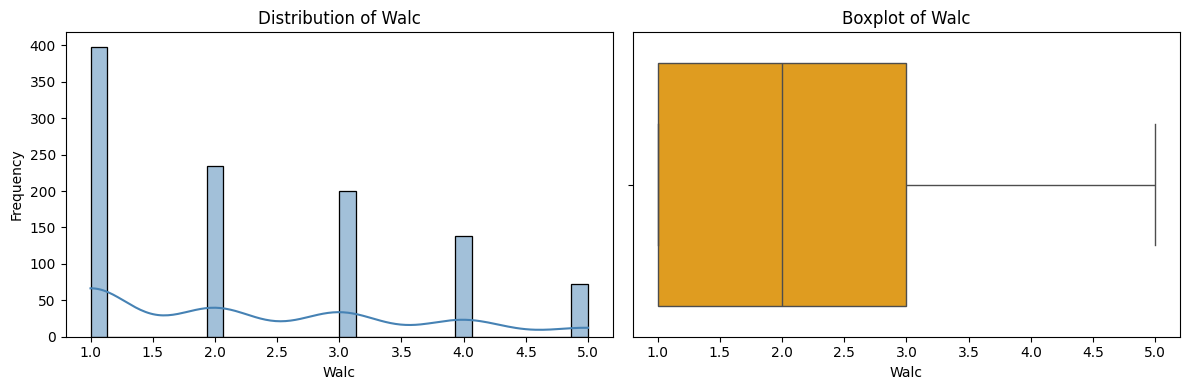

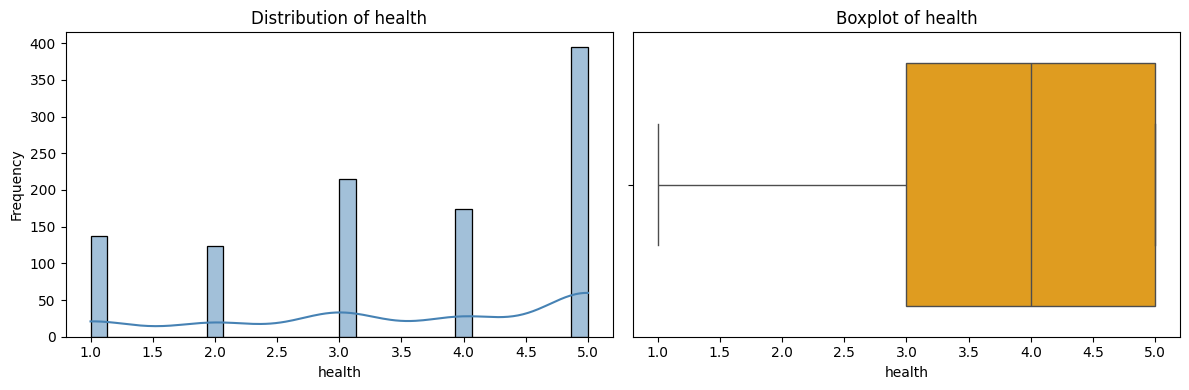

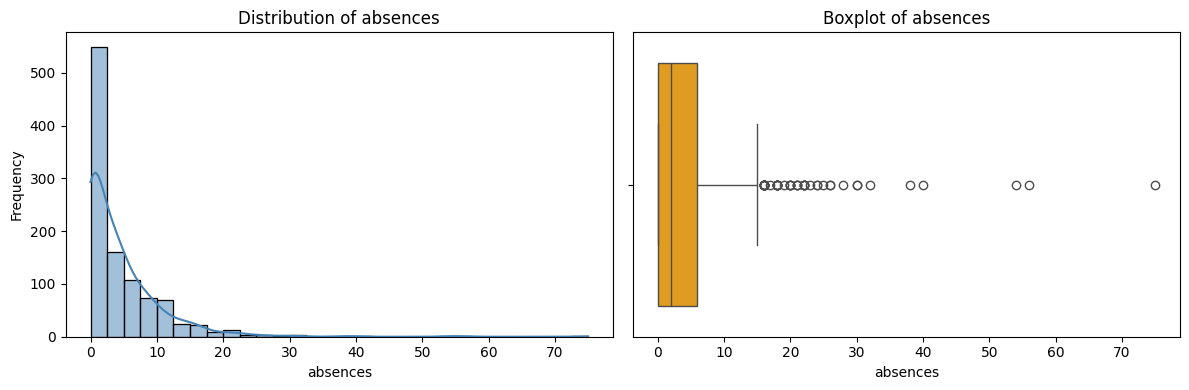

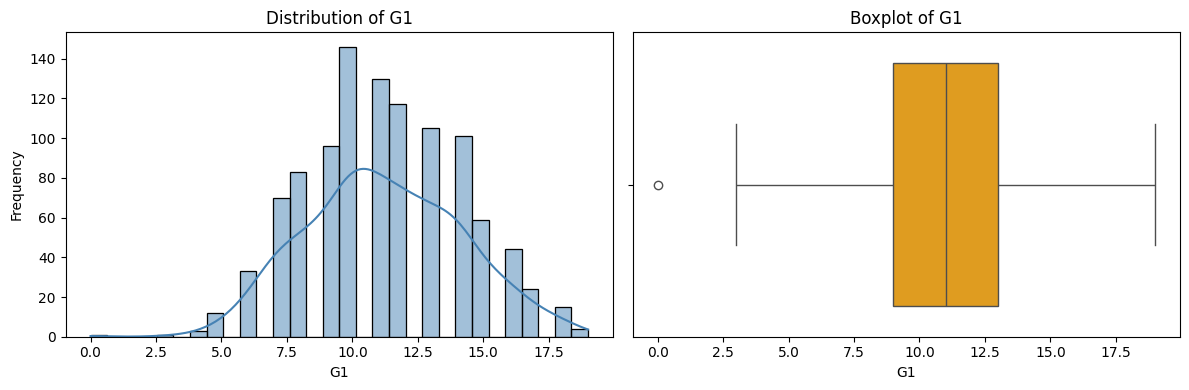

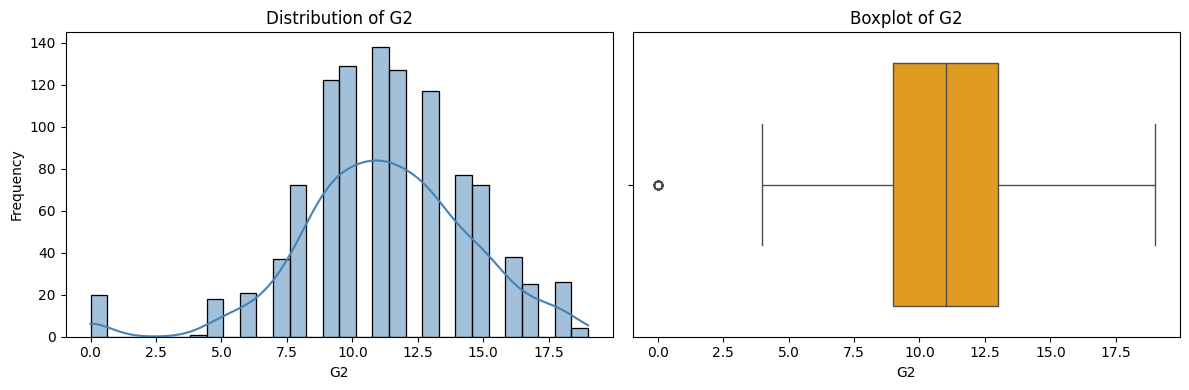

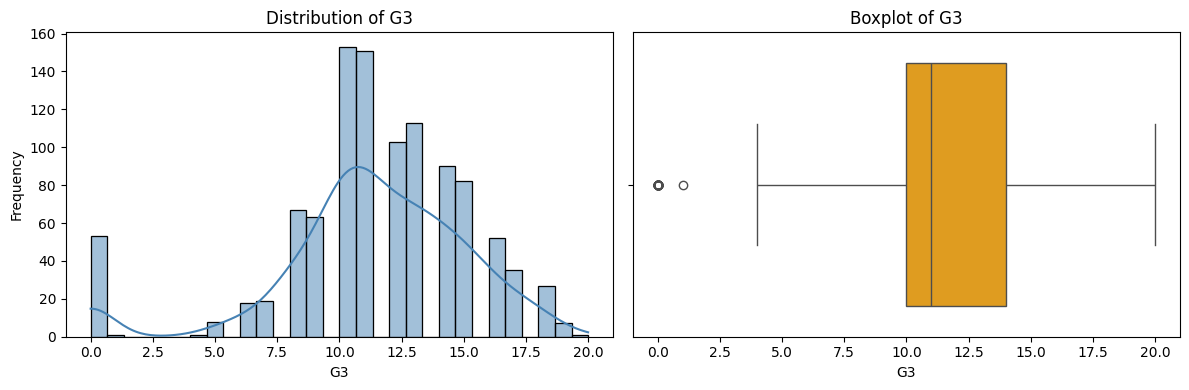

In [67]:
# Variables de types numeriques
numerical_cols = df.select_dtypes(include=["number"]).columns

# Variables de types numeriques continuous
continuous_cols = [col for col in numerical_cols if df[col].nunique()]

# Boucles pour afficher les histogrammes + boxplots pour chaque variables 
for col in continuous_cols:
    plt.figure(figsize=(12, 4))

    # Histogramme avec KDE
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True, bins=30, color='steelblue')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col], color='orange')
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

- **Visual analysis of outliers**

<p style="text-align: justify;">
The boxplots for G1, G2, and G3 show the distribution of students' grades across the three periods. Most grades are concentrated in the middle range, while a few extreme values appear as outliers, particularly at the lower end. This suggests that while most students perform consistently, some students have unusually low scores that deviate from the general pattern.

It can also be observed that some students have a high number of absences. However, this is not necessarily an issue in our context. According to the dataset documentation, some students were rarely present throughout the year, while others were absent for an entire semester.


<span style="color:#1E90FF">**Remark:**</span> The dataset is overall quite clean, with few inconsistencies, which is a positive sign for the reliability of our analysis.

## **3.3 Variable Classification**

<p style="text-align: justify;">
Among the 16 numerical variables, it is important to distinguish truly continuous
variables (G1, G2, G3, Absences) from ordinal-encoded variables (Medu, Fedu,
studytime, traveltime, famrel, freetime, goout, Dalc, Walc, health) which are
technically discrete ordered scales and should be treated accordingly in analysis.
</p>

| Category | Variables |
|----------|-----------|
| **Target** | G3 |
| **Truly continuous** | G1, G2, Absences |
| **Ordinal (encoded)** | Medu, Fedu, studytime, traveltime, famrel, freetime, goout, Dalc, Walc, health |
| **Demographic discrete** | Age, failures |
| **Binary categorical** | school, sex, address, famsize, Pstatus, schoolsup, famsup, paid, activities, nursery, higher, internet, romantic |
| **Nominal categorical** | Mjob, Fjob, reason, guardian |

# 4) **Data Preparation**

**Quick Recap**

<p style="text-align: justify;">
The data preparation phase involves several key steps. First, data cleaning is performed to correct any inconsistencies in the dataset. Next, categorical variables are encoded when necessary to make them suitable for analysis. Finally, variables may be transformed if required to improve the quality or interpretability of the data.
The main corrections will include: standardizing the column names





### 4.1) **Data cleaning (correcting inconsistencies)**

We remove the index here, then eliminate spaces in the variable names, correct extreme values for study time, and finally properly rename the variables.



In [68]:
# Droppinng index column if exist
if "index" in df.columns:
    df.drop("index", axis=1, inplace=True)

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [69]:
# Drop if existint space in column names
for col in df.columns:
    if " " in col:
        new_col = col.replace(" ", "_")
        df.rename(columns={col: new_col}, inplace=True)

In [70]:
# Correction of study time values if they are <= 0
from matplotlib.pylab import mean
x = mean(df["studytime"])
df.loc[df["studytime"] <= 0, "studytime"] = x

In [71]:
# Begin the column names with capital letters and replace spaces with underscores
df.columns = df.columns.str.strip()  # Remove leading/trailing spaces
df.columns = df.columns.str.replace(" ", "_")  # Replace spaces with underscores
df.columns = df.columns.str.capitalize()  # Capitalize the first letter of each column name

In [72]:
# correction of outliers in G1, G2, G3 using IQR method
for col in ["G1", "G2", "G3"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

### 4.2) **Encoding categorical variables if necessary**

Categorical variables were encoded when necessary to ensure compatibility with statistical analyses and machine learning models. This process involves transforming non-numeric variables, such as categories or labels, into numerical representations. Encoding allows the algorithms to correctly interpret the data while preserving the information contained in the original categories. Common techniques include one-hot encoding and label encoding, depending on the type of analysis and the number of categories

In [73]:
# les valeurs de la colonne sexe
print("Dataframe of the 'Sex' column:")
print(df["Sex"].value_counts())


Dataframe of the 'Sex' column:
Sex
F    591
M    453
Name: count, dtype: int64


In [74]:
# Creation d'un varaiables binaire pour le sexe
df["Sex_binary"] = df["Sex"].apply(lambda x: 1 if x == "M" else 0)
print("Dataframe with the new 'Sex_binary' column:")
print(df[["Sex", "Sex_binary"]].head())


Dataframe with the new 'Sex_binary' column:
  Sex  Sex_binary
0   F           0
1   F           0
2   F           0
3   F           0
4   F           0


In [75]:
#- we add some numerical variables to obj features category
obj_columns = df.select_dtypes(include='object').columns.to_list()
new_obj = obj_columns + ['Famrel', 'Freetime', 'Goout', 'Dalc', 'Walc', 'Health', 'Traveltime', 'Studytime', 'Medu', 'Fedu']
len(new_obj)

27

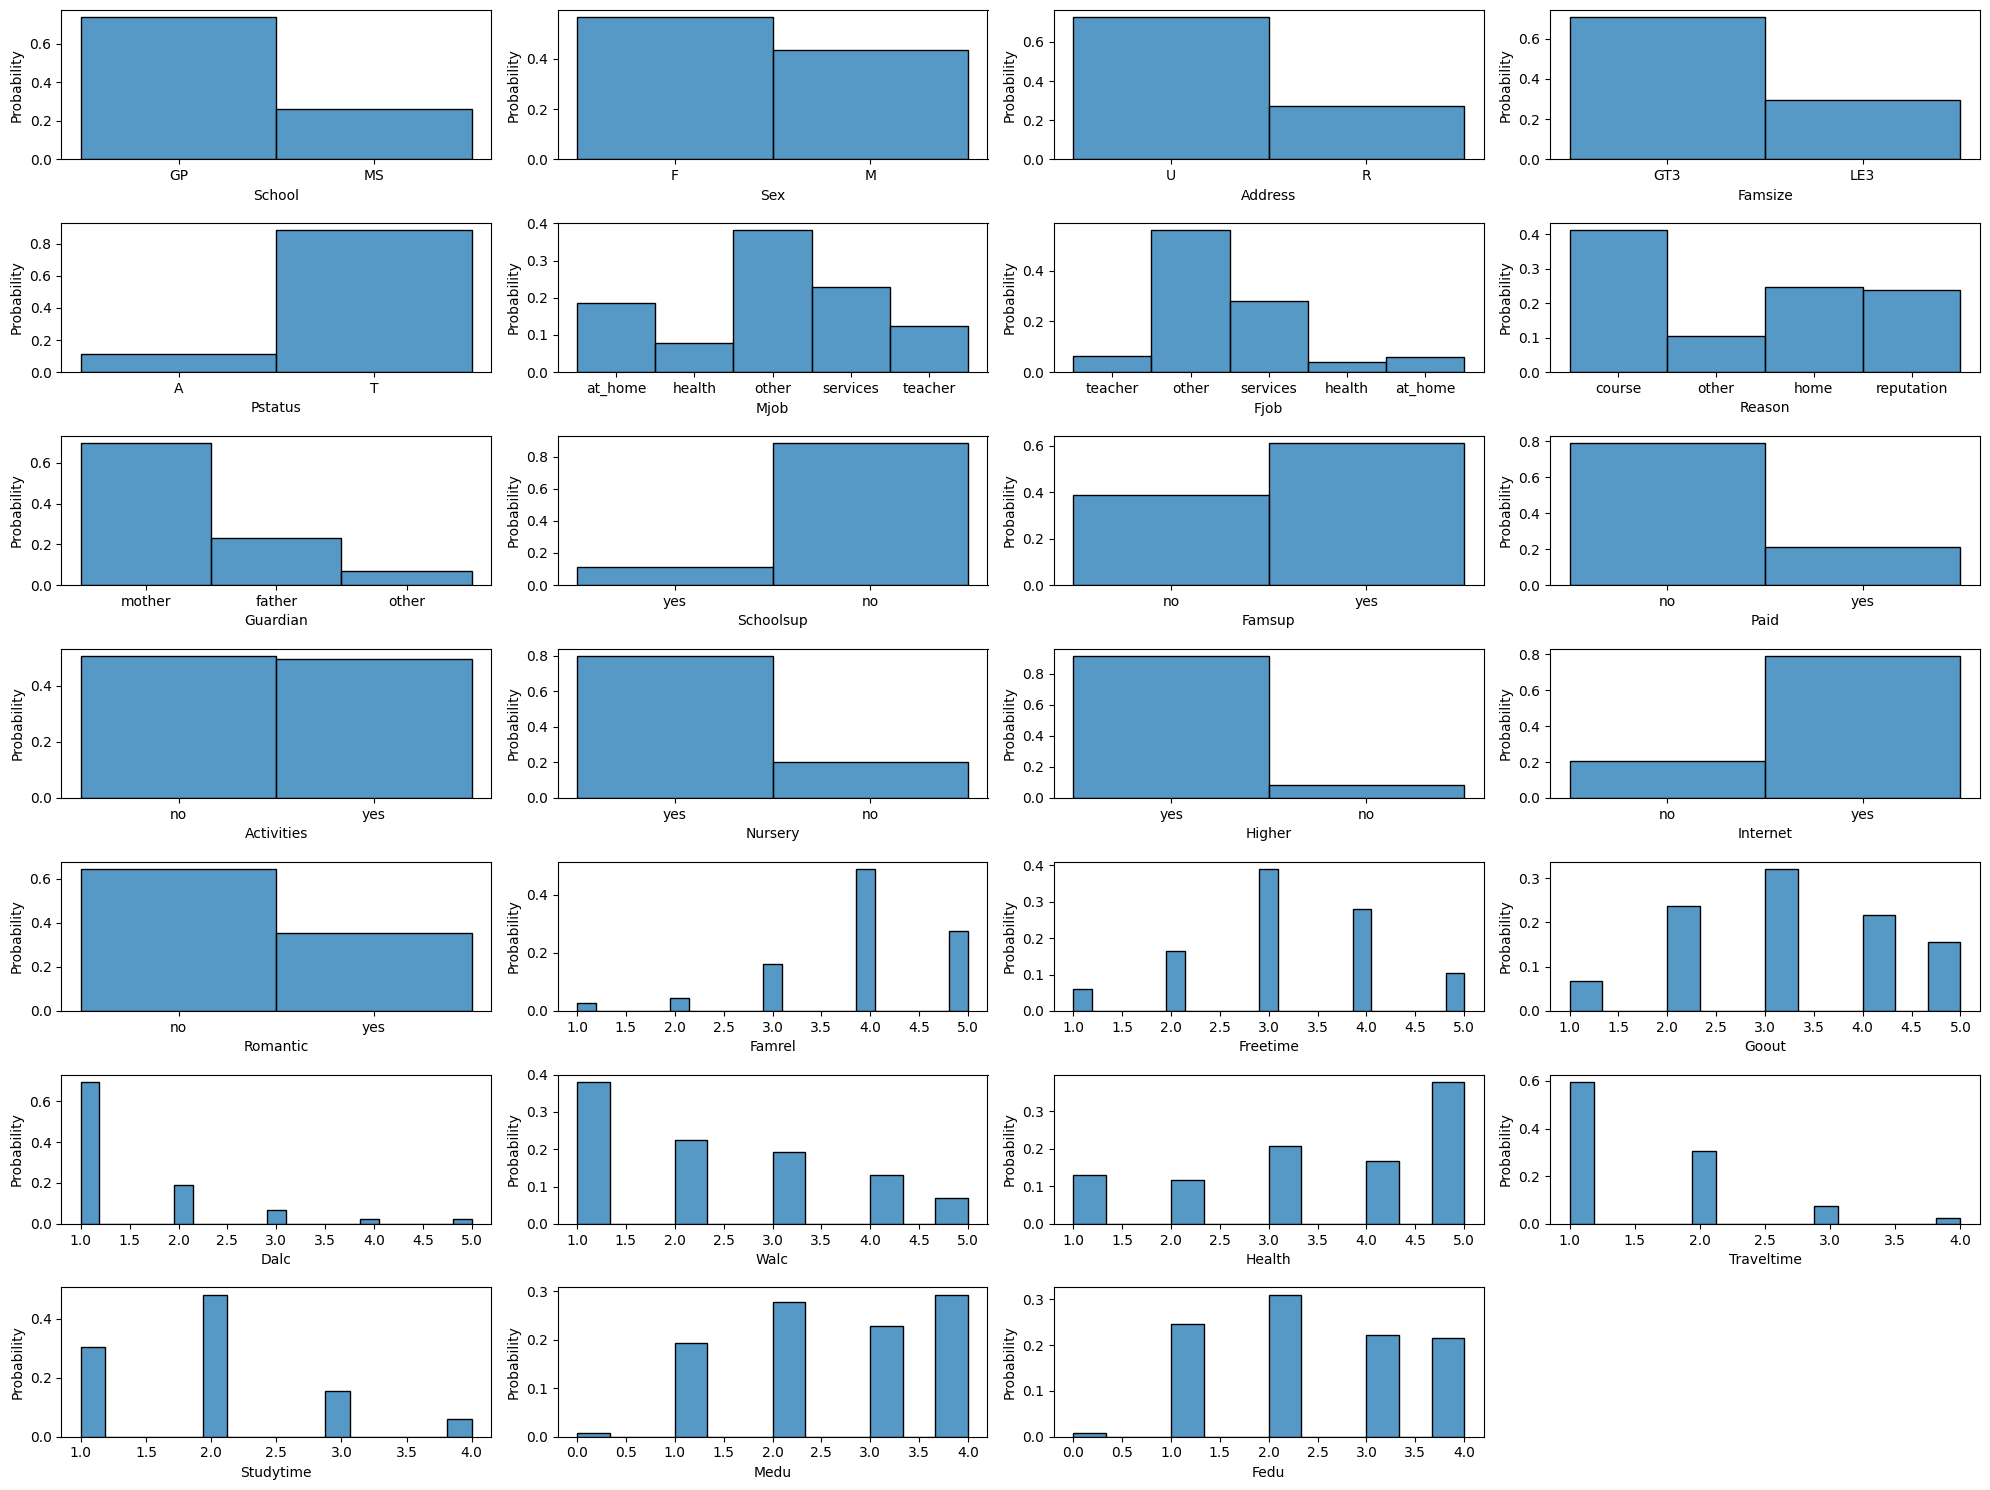

In [76]:
fig = plt.figure(figsize=(20,15))

for index,i in enumerate(new_obj):

  ax = fig.add_subplot(7,4,index+1)
  sns.histplot(data=df, x=i, stat='probability', ax=ax)
  plt.tight_layout()

* most categorical features have obvious diffrence in their specific values except `activities` that `no` and `yes` are equal in overal.
* Most of student overally situation is :   
    1. are in `GP` school.  
    2. are `Female`.
    3. are in `Urban` area.
    4. have `family size` greater than `3`.  
    5. their `parents` live `together`.  
    6. they do `not` have `Extra educational support`.
    7. they have `family support`.
    8. they did `not` pay money for `extra classes`.  
    9. they attended in `nursery school`.
    10. they want to `take higher education`.
    11. they have `internet connection`.
    12. they do `not` have `romantic relationship`.

---

activities feature means student has extra curricular activities or not that its values are equally spread between `yes` and `no`.

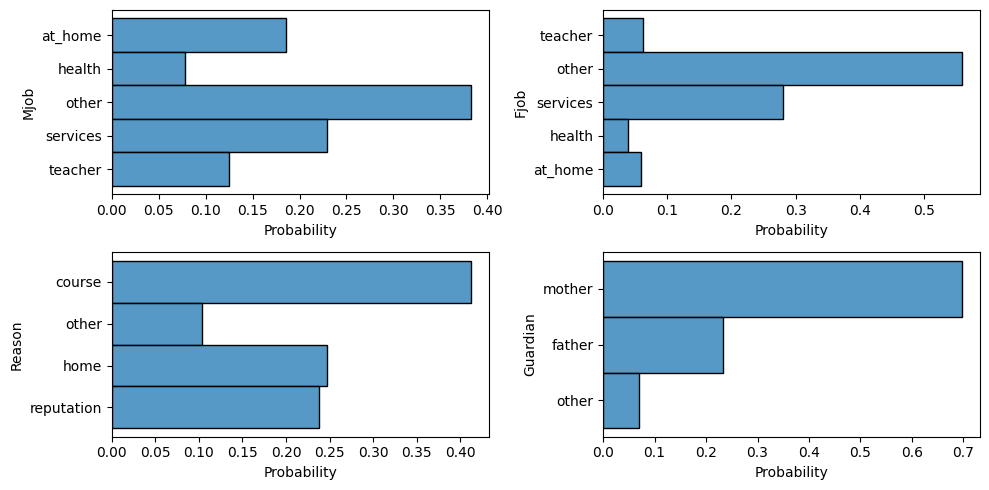

In [77]:
fig = plt.figure(figsize=(10,5))
for index,i in enumerate(['Mjob', 'Fjob', 'Reason', 'Guardian']):
    ax = fig.add_subplot(2,2,index+1)
    sns.histplot(y=df[i], stat='probability', ax=ax)
plt.tight_layout()

in overal between students  
* `50 percent` of Fathers and Mothers work at `services jobs (e.g. administrative or police)` or `other`.  
* most student have their `mother` as their `guardian`.
* `home` and `reputation` have equal involment in reason to choose school.
* `course` of the school has the most involment in reson to choose school.  

With all this results we want to see how much `G1, G2, G3 are spread`

In [78]:
round(df[['G1','G2','G3']].describe().iloc[1:, ], 2)

,G1,G2,G3
mean,11.22,11.30,11.55
std,2.97,3.11,3.32
min,3.00,3.00,4.00
25%,9.00,9.00,10.00
50%,11.00,11.00,11.00
75%,13.00,13.00,14.00
max,19.00,19.00,20.00


here we can see all scores have same mean around `11`, their standard deviations are around `3-4`, minimum is `0` and potential maximum is `20`.  

---

We can have 2 hypothesis:
1. scores of students in one school is equal to other school.  
2. scores of students in one school is normal and in other school is too weak


We use numerci variables that are `not encoded version of Categorical variable`.  
We have `Countable` and `Not Countable` numeric data so we can use `Kernel Density Estimation`.

In [79]:
num_columns = df.select_dtypes(exclude='object').columns.to_list()
set(num_columns) - set(new_obj)

{'Absences', 'Age', 'Failures', 'G1', 'G2', 'G3', 'Sex_binary'}

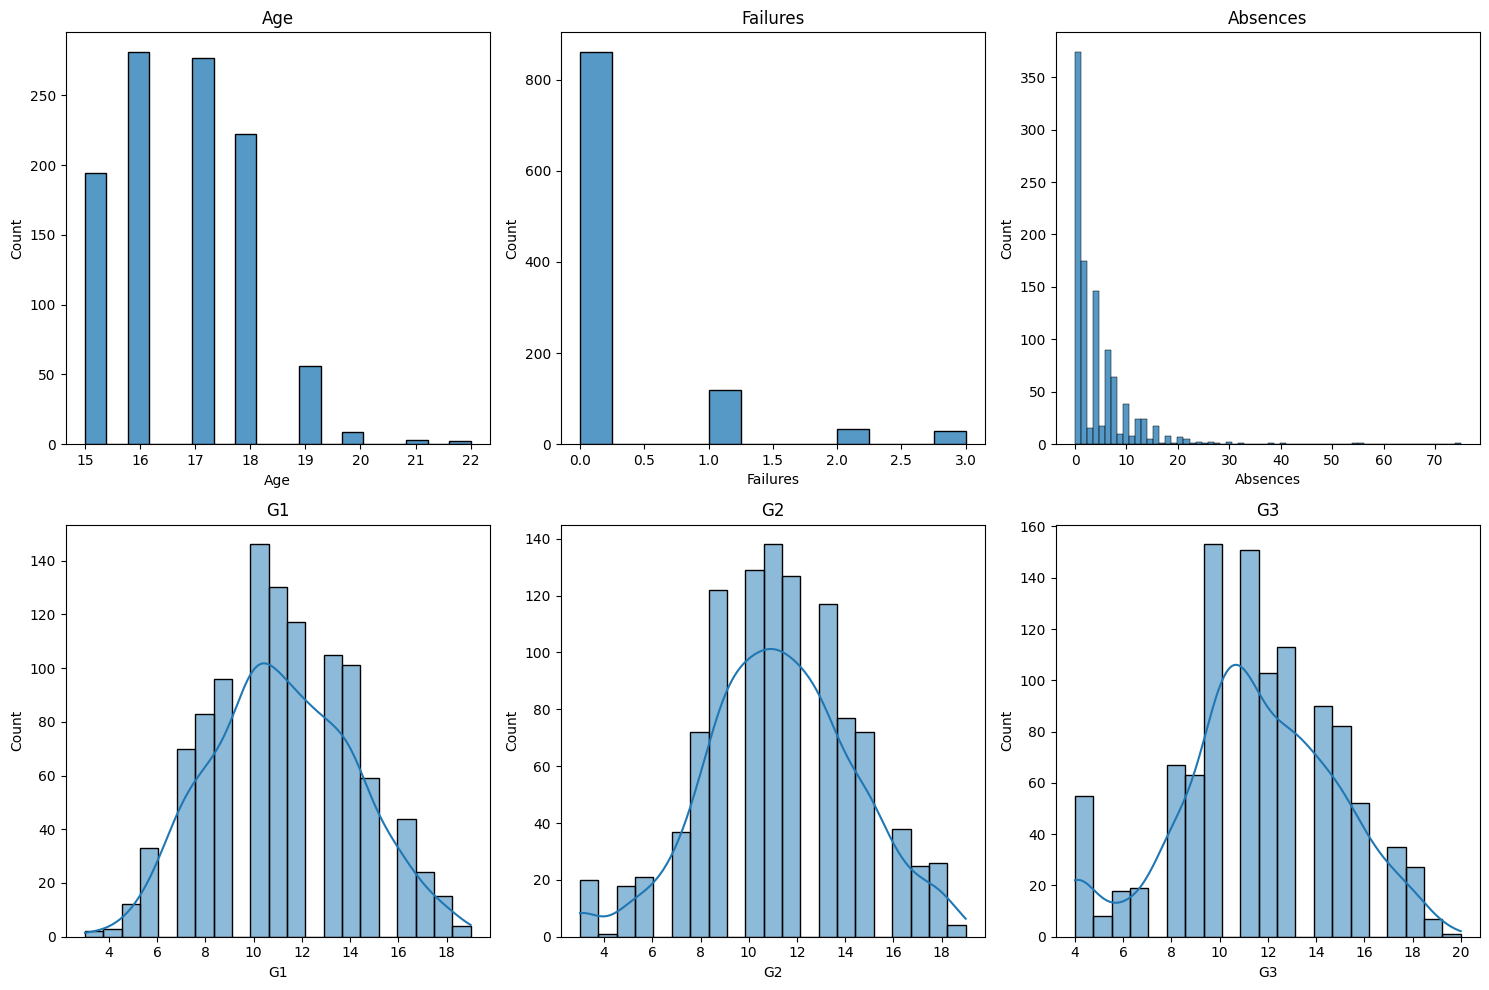

In [80]:

countable = ['Age', 'Failures', 'Absences']
not_countable = ['G1', 'G2', 'G3']

cols = countable + not_countable  # toutes les variables à tracer

n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()

for index, col in enumerate(cols):
    if col in countable:
        sns.histplot(df[col], kde=False, ax=axes[index])
    else:
        sns.histplot(df[col], kde=True, ax=axes[index])
    
    axes[index].set_title(col)

# Supprimer les axes vides (si besoin)
for i in range(len(cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()

Now we move to `Bivariant` and `Multivariant` Analysis.  

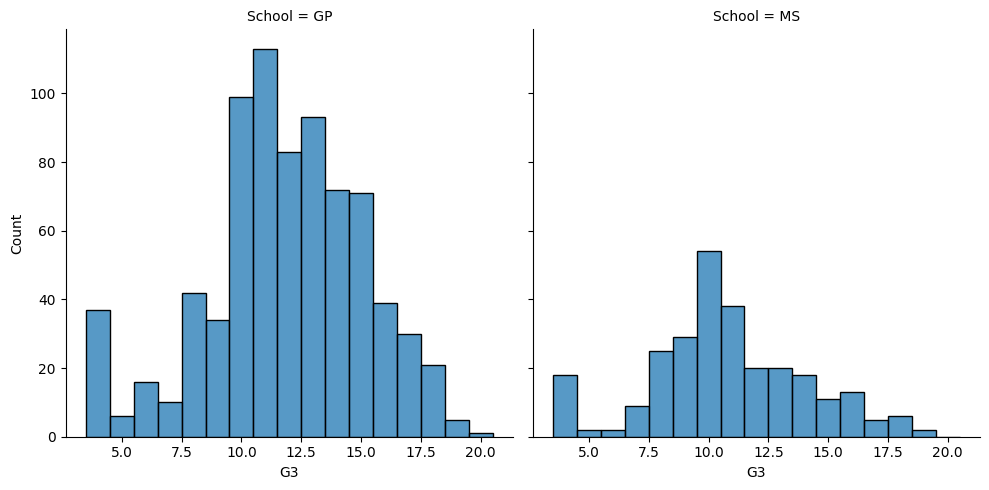

In [81]:
sns.displot(df, x='G3', col="School", discrete=True) # here in dataset G3 is int64 but in reality it is float64 so here we set discrete to true for int64

In [82]:
df[['G3', 'School']].groupby('School').mean()

,G3
School,
GP,11.818653
MS,10.779412


In [83]:
round(df['School'].value_counts(normalize=True), 2)

School
GP    0.74
MS    0.26
Name: proportion, dtype: float64

We have to consider this fact that `school feature` is `imbalance` feature.

lets see originally numeric variable

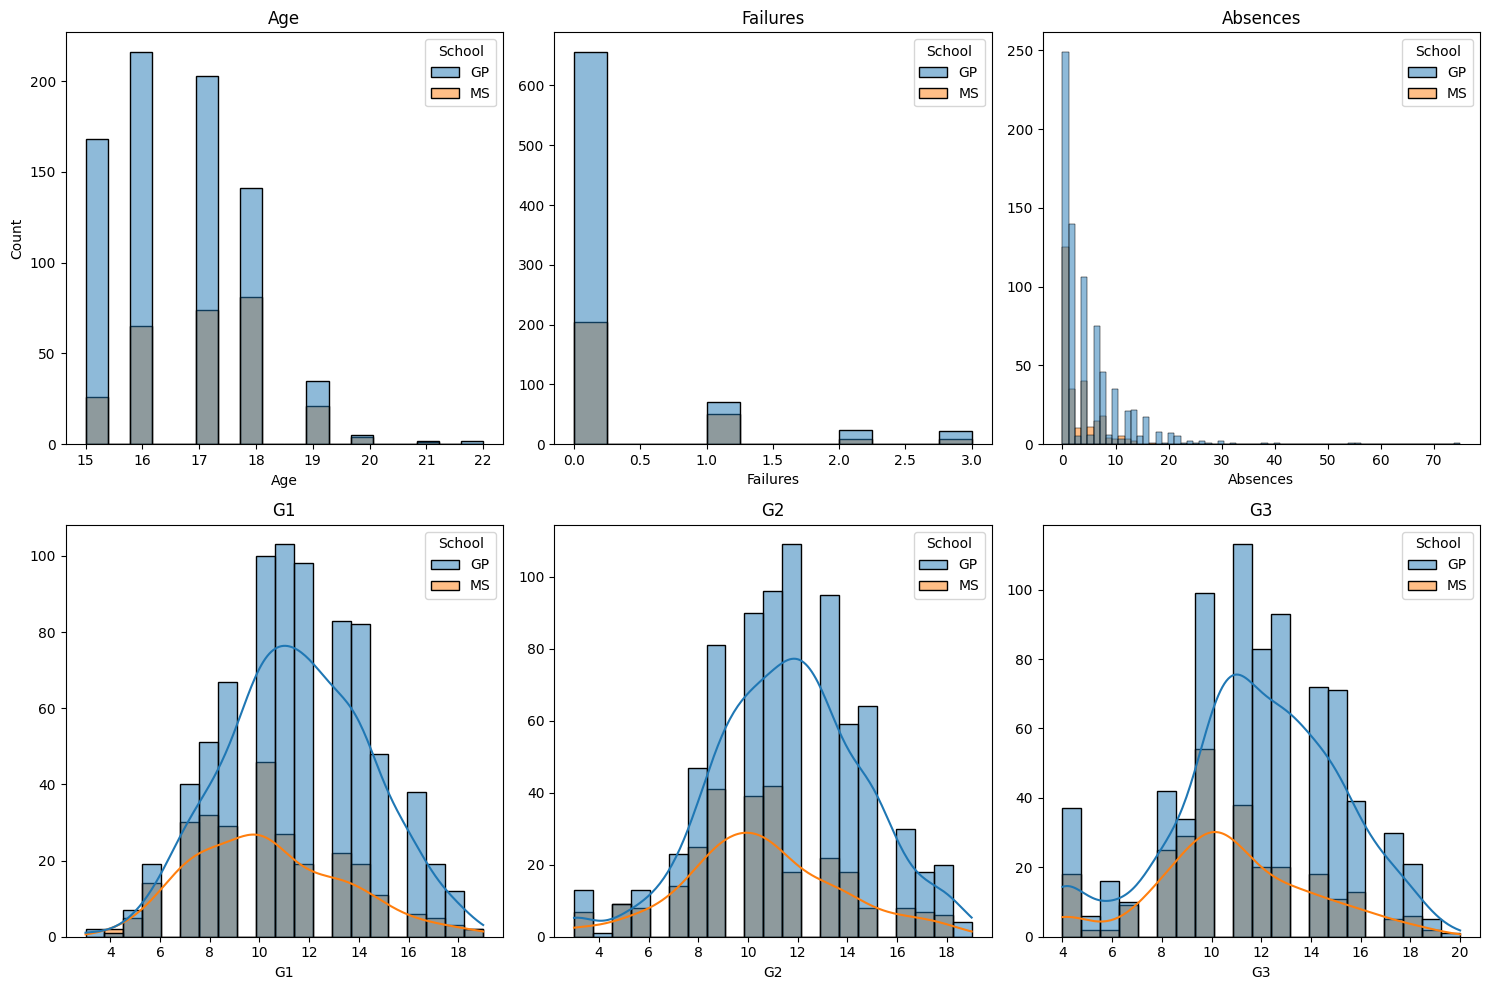

In [84]:
countable = ['Age', 'Failures', 'Absences']
not_countable = ['G1', 'G2', 'G3']

cols = countable + not_countable

n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()

for index, col in enumerate(cols):
    
    if col in countable:
        sns.histplot(data=df, x=col, hue='School', kde=False, ax=axes[index])
    else:
        sns.histplot(data=df, x=col, hue='School', kde=True, ax=axes[index])
    
    axes[index].set_title(col)
    
    if index == 0:
        axes[index].set_ylabel('Count')
    else:
        axes[index].set_ylabel('')

# Supprimer axes vides
for i in range(len(cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()

## **5. Analyse bivariée & tests statistiques**


<p style="text-align: justify;">
The objective of this analysis is to examine the relationship between each explanatory variable and the final performance variable, G3. To facilitate comparisons and enable the use of appropriate statistical tests, a binary outcome variable is first constructed by classifying students into Pass and Fail categories, where a student is considered to have passed if G3 ≥ 10, and failed otherwise.
</p>

In [85]:
# ─────────────────────────────────────────────────────────────────────────────
# 5.0 — CREATION OF THE PASS / FAIL VARIABLE
# ─────────────────────────────────────────────────────────────────────────────
# Standard passing threshold in the Portuguese education system: 10/20.
# This binarization allows us to apply non-parametric tests
# (Mann-Whitney for numerical variables, Chi-square for categorical variables).

df['Pass']       = (df['G3'] >= 10).astype(int)
df['Pass_label'] = df['Pass'].map({1: 'Pass', 0: 'Fail'})

counts    = df['Pass_label'].value_counts()
pass_rate = df['Pass'].mean() * 100

print(f"✔ Pass : {counts['Pass']}  |  ✘ Fail : {counts['Fail']}")
print(f"Overall success rate : {pass_rate:.1f}%")

✔ Pass : 814  |  ✘ Fail : 230
Overall success rate : 78.0%


### **5.1 Numerical Variables vs Pass/Fail**

#### **5.1.1 Boxplots**

Each boxplot compares the distribution of a numerical variable between Pass and Fail groups.
The significance level of the Mann-Whitney U test is shown in each title.

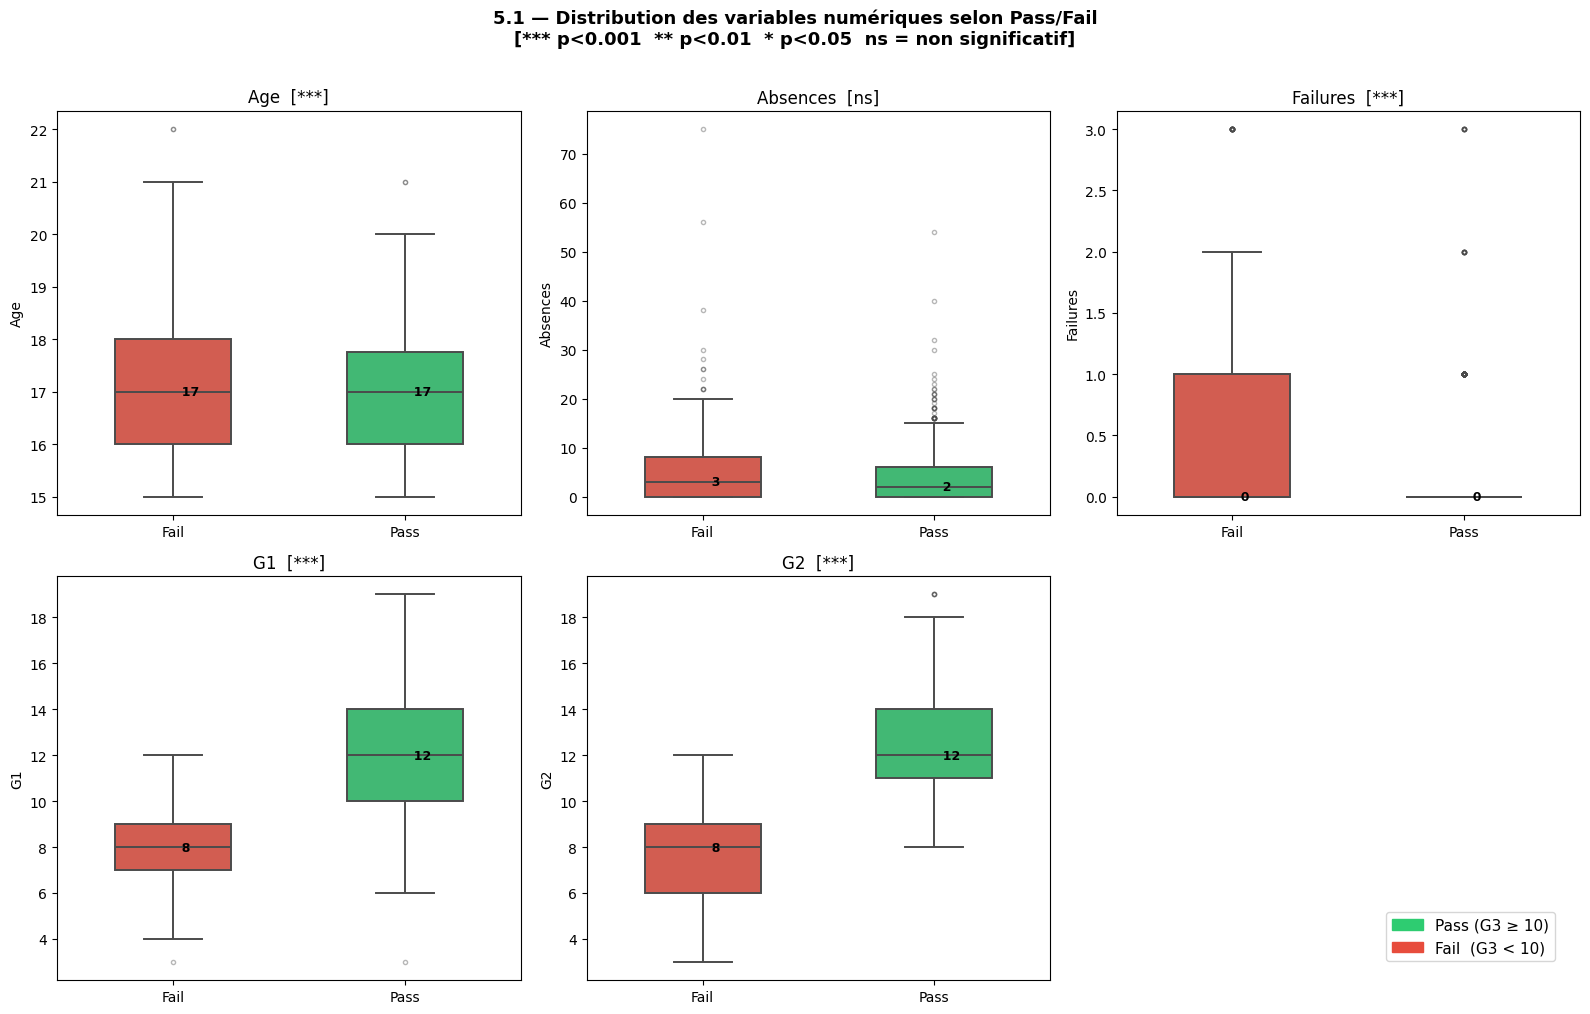

In [86]:
# ─────────────────────────────────────────────────────────────────────────────
# 5.1.1— BOXPLOTS: NUMERICAL VARIABLES vs PASS/FAIL
# ─────────────────────────────────────────────────────────────────────────────
# The boxplot visually compares the distribution of each variable
# between the two groups. The median is annotated for each group.
# The significance level of the Mann-Whitney test is displayed directly
# in the plot title (*** p<0.001, ** p<0.01, * p<0.05, ns = not significant).

num_vars = ['Age', 'Absences', 'Failures', 'G1', 'G2']
palette  = {'Pass': '#2ecc71', 'Fail': '#e74c3c'}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_vars):
    ax = axes[i]

    sns.boxplot(data=df, x='Pass_label', y=col, ax=ax,
                palette=palette, order=['Fail', 'Pass'],
                width=0.5, linewidth=1.4,
                flierprops=dict(marker='o', markersize=3, alpha=0.4))

    # Annotation des médianes
    for j, group in enumerate(['Fail', 'Pass']):
        med = df[df['Pass_label'] == group][col].median()
        ax.text(j, med, f'  {med:.0f}', va='center', ha='left',
                fontsize=9, fontweight='bold')

    # Test Mann-Whitney préliminaire pour l'annotation
    stat, p = mannwhitneyu(df[df['Pass']==1][col],
                            df[df['Pass']==0][col], alternative='two-sided')
    sig = ('***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns')
    ax.set_title(f'{col}  [{sig}]')
    ax.set_xlabel('')
    ax.set_ylabel(col)

fig.delaxes(axes[5])  # Supprimer le 6e axe vide

# Légende
pass_p = mpatches.Patch(color='#2ecc71', label='Pass (G3 ≥ 10)')
fail_p = mpatches.Patch(color='#e74c3c', label='Fail  (G3 < 10)')
fig.legend(handles=[pass_p, fail_p], loc='lower right',
           bbox_to_anchor=(0.98, 0.05), fontsize=11, frameon=True)

fig.suptitle('5.1 — Distribution des variables numériques selon Pass/Fail\n'
             '[*** p<0.001  ** p<0.01  * p<0.05  ns = non significatif]',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


<p style="text-align: justify;">
The figure shows clear differences between Pass and Fail students for most variables. G1 and G2 are much higher for students who pass, indicating strong predictive power of early grades. The number of failures is also higher among students who fail, confirming its importance. In contrast, age shows almost no difference between groups. Absences are not clearly significant, with strong overlap between distributions.
</p>

#### **5.1.2 Mann-Whitney U Test + Effect Size**

We use the **Mann-Whitney U test** (non-parametric alternative to the t-test) because
the distributions of G1, G2, Failures, and Absences are not normally distributed.
The **rank-biserial correlation r** measures effect size:
- r < 0.10 → negligible | 0.10–0.30 → small | 0.30–0.50 → medium | > 0.50 → large

In [87]:
# ─────────────────────────────────────────────────────────────────────────────
# 5.1.2 — HYPOTHESES
# ─────────────────────────────────────────────────────────────────────────────

# H1 (G1, G2) : Students who pass G3 have significantly higher previous grades
#               → past performance is the dominant predictor.
#
# H2 (Failures) : More previous failures → higher probability of failing G3.
#                 Strong signal of progressive disengagement.
#
# H3 (Absences) : Higher absenteeism is associated with failure,
#                 but with substantial dispersion (outliers).
#
# H4 (Age) : Older students tend slightly more toward failure
#            (possible grade repetition, different engagement level).

#### **5.1.3 Commentary**

Beyond G1 and G2 (r > 0.85), **Failures** is the only exogenous variable with a
moderate effect on Pass/Fail (r ≈ 0.35, p < 0.001), while Age and Absences remain
weak or non-significant. This confirms that prior academic trajectory is the
dominant driver of final performance.

In [88]:
# 5.1.3 — MANN-WHITNEY U TEST (with rank-biserial r)
# ─────────────────────────────────────────────────────────────────────────────
# Why Mann-Whitney instead of a t-test?
# → The distributions of G1, G2, Failures, Absences do not follow a normal
#   distribution (skewness, peaks), which would be checked using a
#   Shapiro-Wilk test.
# → Mann-Whitney is a robust non-parametric alternative to the t-test.
#
# Effect size: rank-biserial r = 1 - 2U / (n1 * n2)
#   r ≈ 0.1 → small  |  r ≈ 0.3 → medium  |  r ≈ 0.5 → large

pass_grp = df[df['Pass'] == 1]
fail_grp = df[df['Pass'] == 0]

mw_results = []
for col in num_vars:
    stat, p = mannwhitneyu(pass_grp[col], fail_grp[col], alternative='two-sided')
    n1, n2  = len(pass_grp[col]), len(fail_grp[col])
    r       = abs(1 - (2 * stat) / (n1 * n2))   # rank-biserial (taille d'effet)
    direction = '↑ Pass > Fail' if pass_grp[col].median() > fail_grp[col].median() \
                else '↓ Fail > Pass'

    mw_results.append({
        'Variable'     : col,
        'Médiane Pass' : round(pass_grp[col].median(), 1),
        'Médiane Fail' : round(fail_grp[col].median(), 1),
        'U statistic'  : int(stat),
        'p-value'      : round(p, 4),
        'Sig.'         : '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns',
        'r (effet)'    : round(r, 3),
        'Direction'    : direction
    })

df_mw = pd.DataFrame(mw_results).set_index('Variable')
print("\n── 5.1.3 TEST DE MANN-WHITNEY U ──────────────────────────────────")
display(df_mw)


── 5.1.3 TEST DE MANN-WHITNEY U ──────────────────────────────────


,Médiane Pass,Médiane Fail,U statistic,p-value,Sig.,r (effet),Direction
Variable,,,,,,,
Age,17.0,17.0,77418,0.0000,***,0.173,↓ Fail > Pass
Absences,2.0,3.0,86957,0.0912,ns,0.071,↓ Fail > Pass
Failures,0.0,0.0,61163,0.0000,***,0.347,↓ Fail > Pass
G1,12.0,8.0,175060,0.0000,***,0.870,↑ Pass > Fail
G2,12.0,8.0,181181,0.0000,***,0.935,↑ Pass > Fail


### 5.2 **Categorical Variables vs Pass/Fail**

#### **5.2.1 Stacked Barplots**

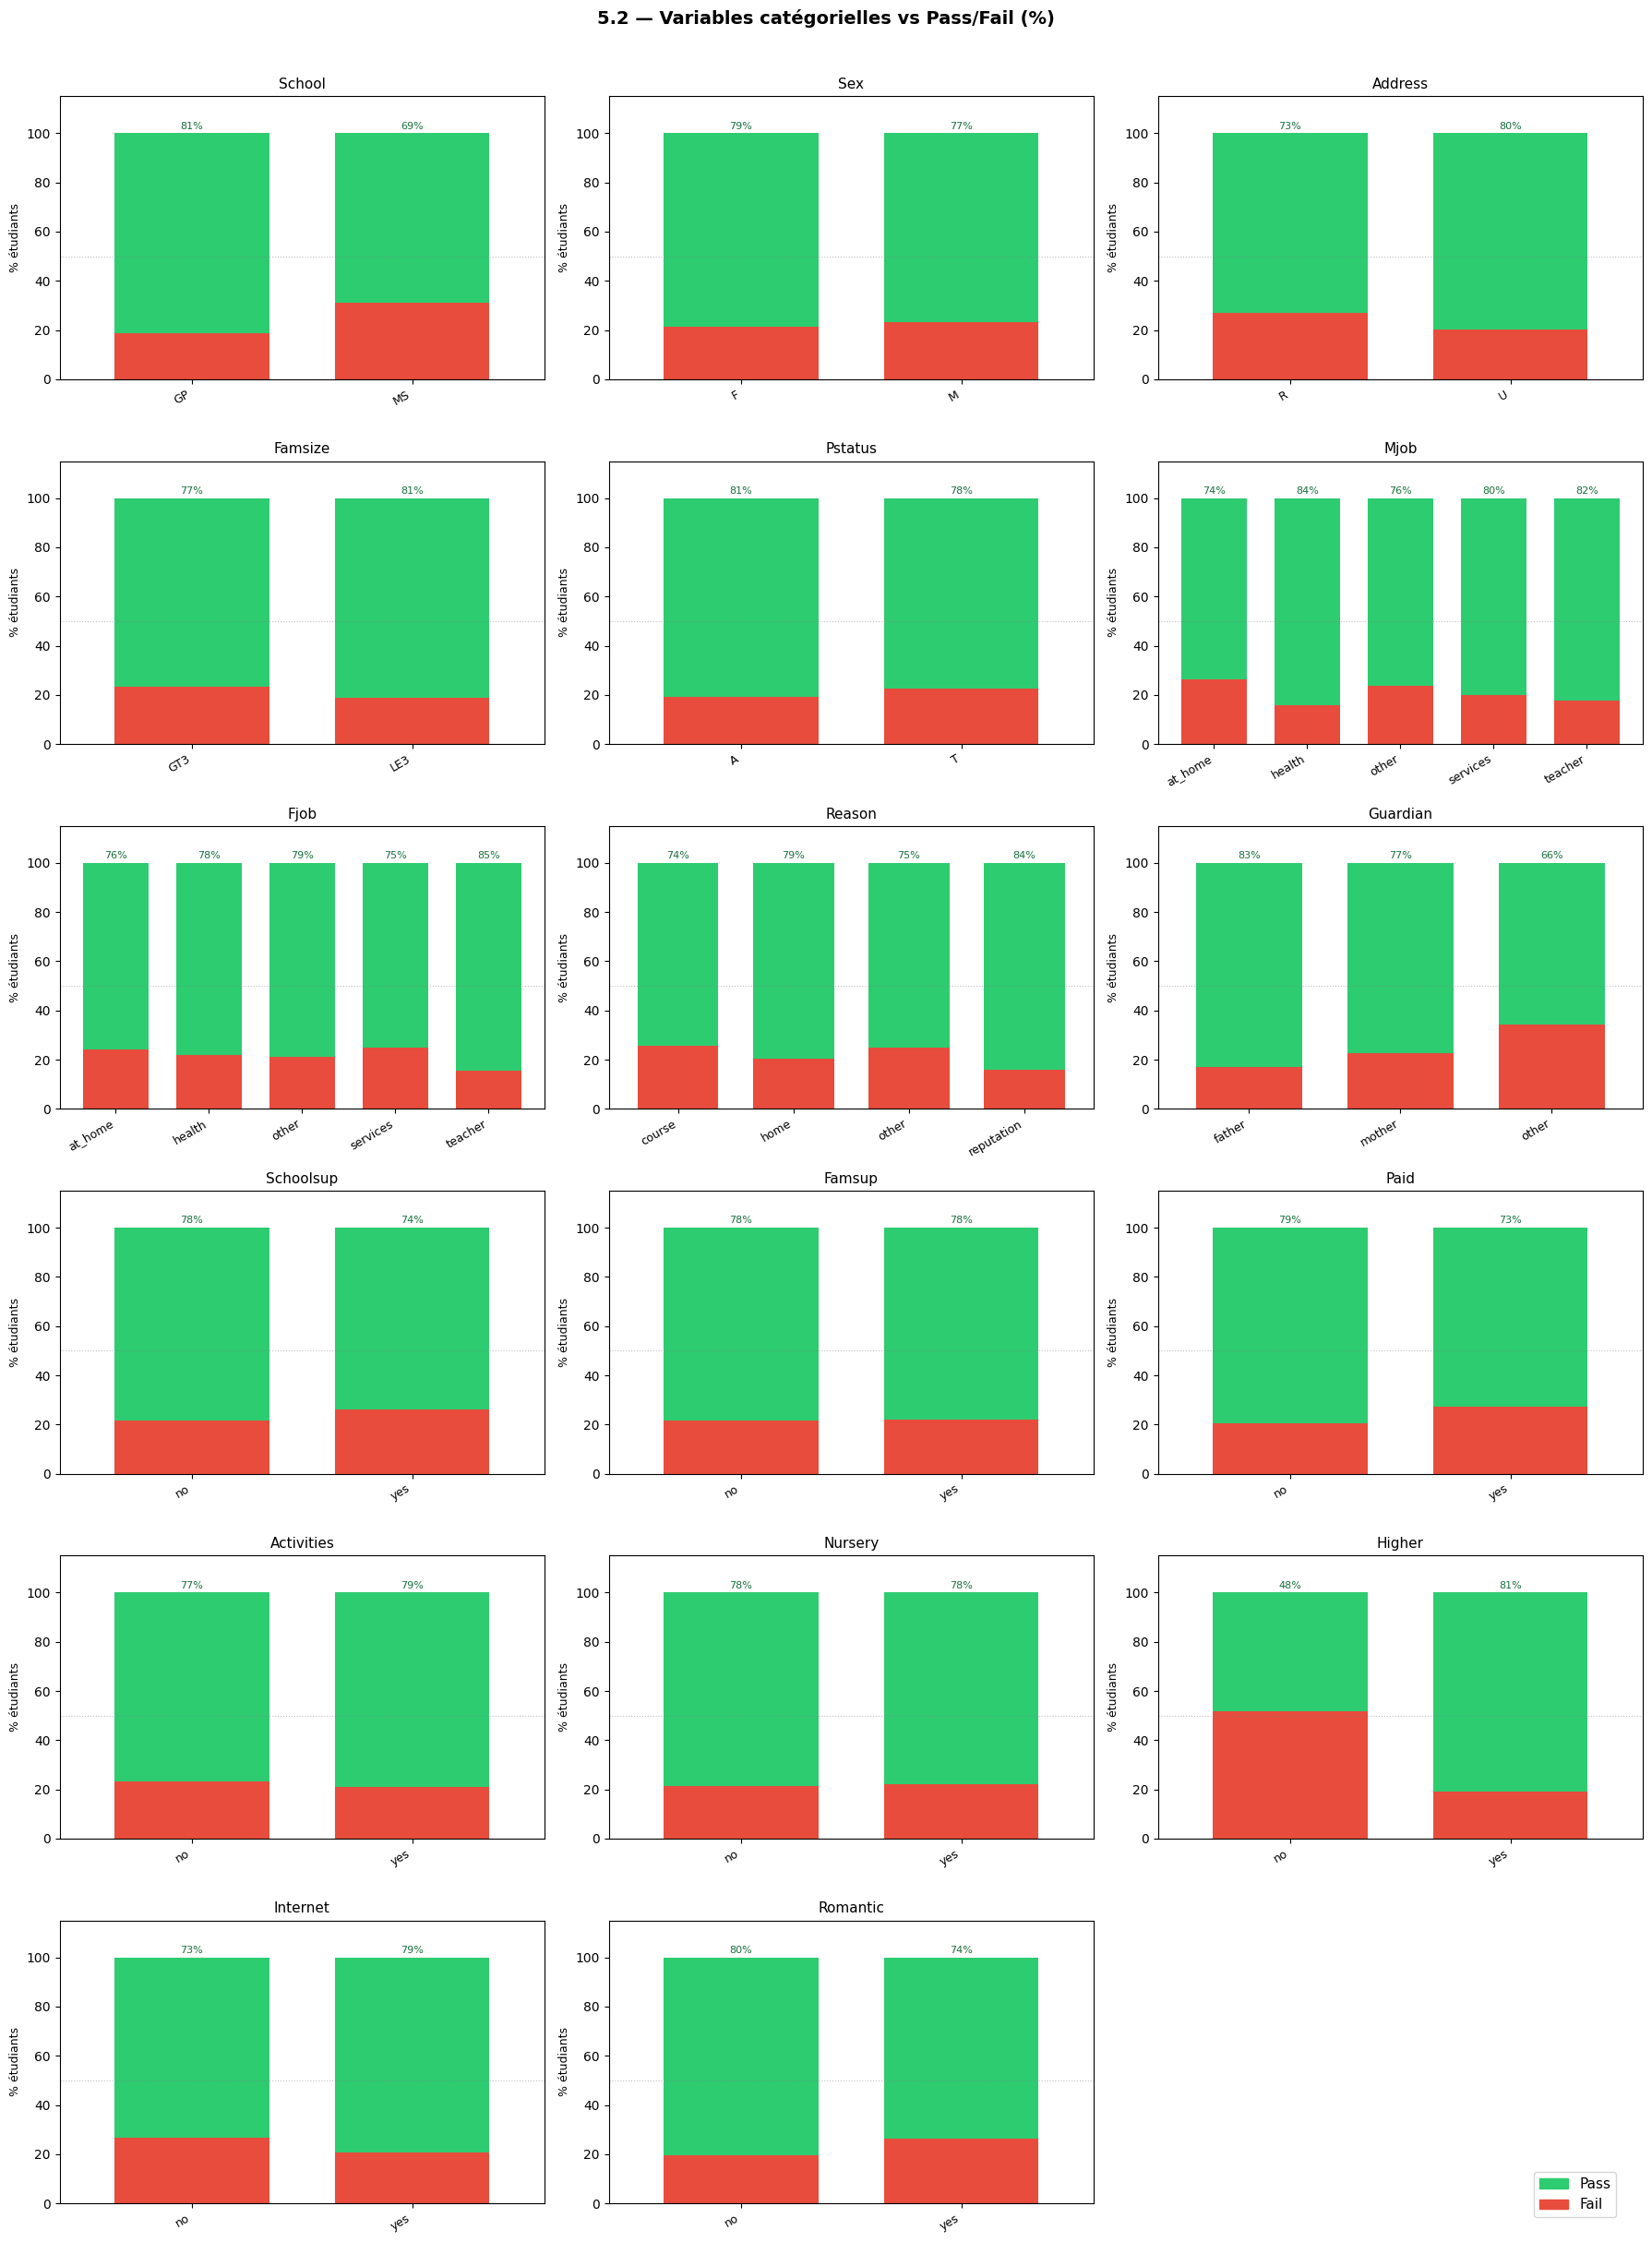

In [89]:
# ─────────────────────────────────────────────────────────────────────────────
# 5.2.1 — STACKED BAR PLOTS: CATEGORICAL VARIABLES vs PASS/FAIL
# ─────────────────────────────────────────────────────────────────────────────
# Each bar represents 100% of students within a category, split into
# Pass (green) and Fail (red). The % of Pass is annotated at the top of each
# bar to improve readability.

cat_vars = [c for c in df.select_dtypes(include='object').columns
            if c not in ['Pass_label']]

n_cols = 3
n_rows = math.ceil(len(cat_vars) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_vars):
    ax = axes[i]
    data     = df.groupby([col, 'Pass_label']).size().unstack(fill_value=0)
    data_pct = data.div(data.sum(axis=1), axis=0) * 100
    data_pct = data_pct.reindex(columns=['Fail', 'Pass'])

    data_pct.plot(kind='bar', stacked=True, ax=ax,
                  color=['#e74c3c', '#2ecc71'], legend=False, width=0.7)

    # Annotation % Pass au-dessus de chaque barre
    for j, (_, row) in enumerate(data_pct.iterrows()):
        ax.text(j, 101, f"{row.get('Pass', 0):.0f}%",
                ha='center', va='bottom', fontsize=8, color='#196f3d')

    ax.set_title(col, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('% étudiants', fontsize=9)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
    ax.set_ylim(0, 115)
    ax.axhline(50, color='gray', linestyle=':', alpha=0.5, linewidth=0.8)

for j in range(len(cat_vars), len(axes)):
    fig.delaxes(axes[j])

pass_p = mpatches.Patch(color='#2ecc71', label='Pass')
fail_p = mpatches.Patch(color='#e74c3c', label='Fail')
fig.legend(handles=[pass_p, fail_p], loc='lower right',
           bbox_to_anchor=(0.98, 0.01), fontsize=11, frameon=True)

fig.suptitle('5.2 — Variables catégorielles vs Pass/Fail (%)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


<p style="text-align: justify;">
The stacked bar plots show clear differences in pass/fail rates across categorical variables. Students with higher education aspirations (Higher = yes) and better academic support tend to have higher pass rates. Overall, some variables (especially Higher and Guardian) appear more strongly associated with performance than others.
</p>

#### **5.2.2 Chi² Test + Cramér's V**

The **Chi² test** assesses whether Pass/Fail distribution is independent of each
categorical variable. **Cramér's V** measures the strength of association:
- V < 0.10 → weak | 0.10–0.30 → moderate | > 0.30 → strong

In [90]:
# ─────────────────────────────────────────────────────────────────────────────
# 5.2.2 — HYPOTHESES (categorical variables)
# ─────────────────────────────────────────────────────────────────────────────
#
# H5 (Higher education aspiration): Students who aspire to higher education have
#                                  a significantly higher success rate → motivation is a key driver.
#
# H6 (Internet): Having home internet access facilitates study and is associated
#                with better academic performance.
#
# H7 (Schoolsup): Academic support is more common among struggling students —
#                 which explains the higher failure rate in this group (selection bias,
#                 not a negative causal effect).
#
# H8 (Sex): Difference in success rates between males and females.
#           To be formally tested using the Chi-square test.

In [91]:
# ─────────────────────────────────────────────────────────────────────────────
# 5.2.3 — CHI-SQUARE TEST + CRAMÉR'S V
# ─────────────────────────────────────────────────────────────────────────────
# The Chi-square test assesses whether the Pass/Fail distribution is independent
# of the categorical variable → H0: independence.
#
# Cramér's V measures the STRENGTH of the association (independent of sample size):
#   V = sqrt( Chi² / (n × min(r-1, c-1)) )
#   V < 0.10 → weak  |  0.10 – 0.30 → moderate  |  > 0.30 → strong

chi2_results = []
for col in cat_vars:
    ct               = pd.crosstab(df[col], df['Pass_label'])
    chi2_stat, p, dof, _ = chi2_contingency(ct)
    n                = ct.sum().sum()
    min_dim          = min(ct.shape) - 1
    cramer_v         = np.sqrt(chi2_stat / (n * min_dim)) if min_dim > 0 else np.nan
    intensity        = 'Fort' if cramer_v > 0.3 else ('Modéré' if cramer_v > 0.1 else 'Faible')

    chi2_results.append({
        'Variable'   : col,
        'Chi²'       : round(chi2_stat, 2),
        'ddl'        : dof,
        'p-value'    : round(p, 4),
        'Sig.'       : '✓' if p < 0.05 else '✗',
        "Cramér's V" : round(cramer_v, 3),
        'Effet'      : intensity
    })

df_chi2 = (pd.DataFrame(chi2_results)
             .set_index('Variable')
             .sort_values("Cramér's V", ascending=False))

print("\n── 5.2.3 TEST CHI² + CRAMÉR'S V ")
display(df_chi2)



── 5.2.3 TEST CHI² + CRAMÉR'S V 


,Chi²,ddl,p-value,Sig.,Cramér's V,Effet
Variable,,,,,,
Higher,47.94,1,0.0000,✓,0.214,Modéré
School,17.48,1,0.0000,✓,0.129,Modéré
Reason,10.21,3,0.0169,✓,0.099,Faible
Guardian,10.21,2,0.0061,✓,0.099,Faible
Mjob,6.56,4,0.1613,✗,0.079,Faible
Romantic,6.05,1,0.0139,✓,0.076,Faible
Address,5.28,1,0.0215,✓,0.071,Faible
Paid,4.08,1,0.0434,✓,0.063,Faible
Fjob,3.66,4,0.4542,✗,0.059,Faible


#### **5.2.3 Commentary**

The Chi² tests reveal that most categorical variables have a weak association with
Pass/Fail. **Higher** stands out as the only variable with a moderate effect
(V=0.214, p<0.001): students aspiring to higher education pass at a significantly
higher rate, confirming motivation as a key driver of academic success. **School**
also shows a moderate association (V=0.129, p<0.001), suggesting an institutional
effect between GP and MS. **Reason**, **Guardian**, **Romantic**, **Address** and
**Paid** are statistically significant but with negligible effect sizes (V<0.10),
meaning their practical relevance is limited. The remaining variables — including
**Sex**, **Schoolsup**, **Famsize**, and **Famsup** — show no significant association
with Pass/Fail whatsoever (p>0.05, V<0.05).

### **5.3 Synthesis: Effect Size Summary**

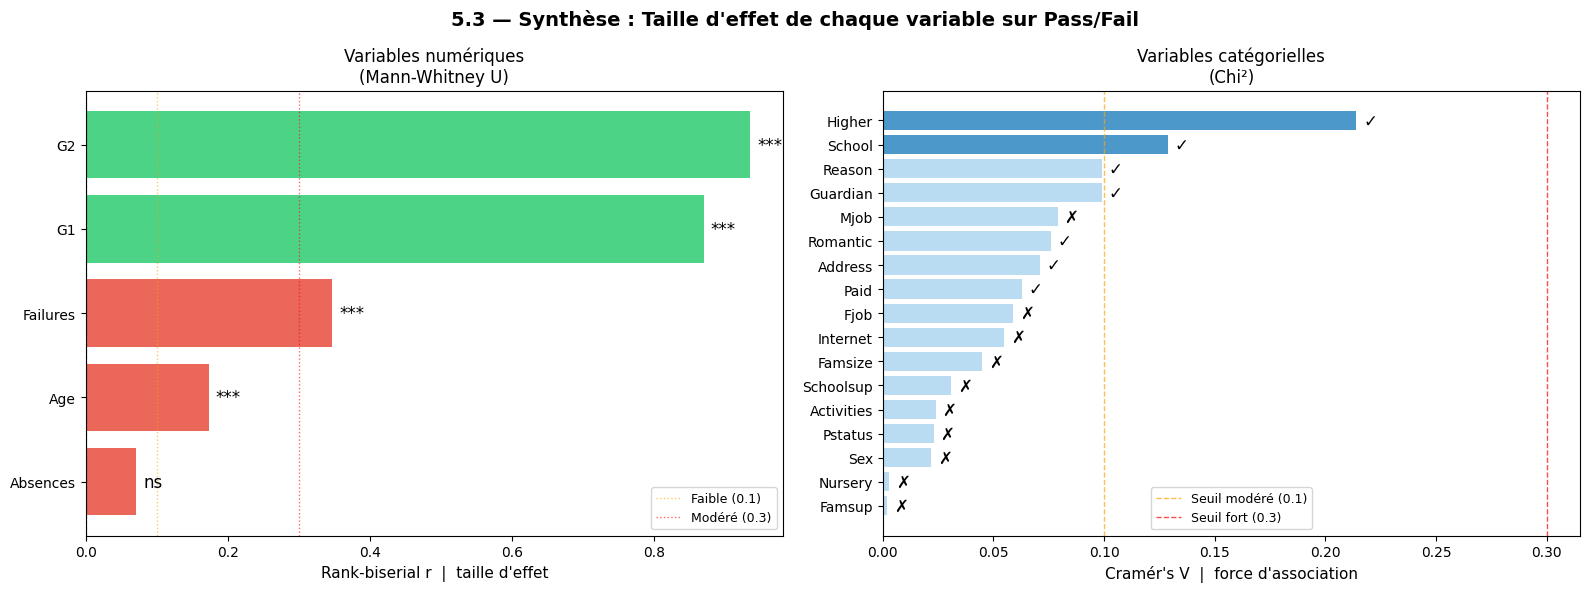

In [92]:
# ─────────────────────────────────────────────────────────────────────────────
# 5.3 — VISUAL SYNTHESIS: STRENGTH OF ASSOCIATIONS
# ─────────────────────────────────────────────────────────────────────────────
# Side-by-side comparison plot:
#   - Left: rank-biserial r for numerical variables
#   - Right: Cramér's V for categorical variables
# This type of dot/bar plot is standard in academic publications
# to summarize predictor relevance (cf. Cortez & Silva, 2008).

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Gauche : rank-biserial r ---
df_mw_s = df_mw.sort_values('r (effet)', ascending=True)
colors_r = ['#e74c3c' if '↓' in d else '#2ecc71' for d in df_mw_s['Direction']]
bars = axes[0].barh(df_mw_s.index, df_mw_s['r (effet)'], color=colors_r, alpha=0.85)

for bar, sig in zip(bars, df_mw_s['Sig.']):
    axes[0].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 sig, va='center', fontsize=12)

axes[0].axvline(0,   color='black', linewidth=0.8, linestyle='--')
axes[0].axvline(0.1, color='orange', linewidth=1, linestyle=':', alpha=0.6, label='Faible (0.1)')
axes[0].axvline(0.3, color='red',    linewidth=1, linestyle=':', alpha=0.6, label='Modéré (0.3)')
axes[0].set_xlabel("Rank-biserial r  |  taille d'effet", fontsize=11)
axes[0].set_title("Variables numériques\n(Mann-Whitney U)", fontsize=12)
axes[0].legend(fontsize=9)

# --- Droite : Cramér's V ---
df_c_s    = df_chi2.sort_values("Cramér's V", ascending=True)
colors_cv = ['#2E86C1' if v > 0.1 else '#aed6f1' for v in df_c_s["Cramér's V"]]
bars2 = axes[1].barh(df_c_s.index, df_c_s["Cramér's V"], color=colors_cv, alpha=0.85)

for bar, sig in zip(bars2, df_c_s['Sig.']):
    axes[1].text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
                 sig, va='center', fontsize=12)

axes[1].axvline(0.1, color='orange', linewidth=1, linestyle='--', alpha=0.7, label='Seuil modéré (0.1)')
axes[1].axvline(0.3, color='red',    linewidth=1, linestyle='--', alpha=0.7, label='Seuil fort (0.3)')
axes[1].set_xlabel("Cramér's V  |  force d'association", fontsize=11)
axes[1].set_title("Variables catégorielles\n(Chi²)", fontsize=12)
axes[1].legend(fontsize=9)

fig.suptitle("5.3 — Synthèse : Taille d'effet de chaque variable sur Pass/Fail",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Beyond G1 and G2 (r>0.85), **Failures** is the only exogenous variable with a
moderate effect on Pass/Fail (r≈0.35, p<0.001), while Age and Absences remain weak.
Among categorical variables, only **Higher** (V=0.21) and **School** (V=0.13) show
a meaningful association; all others fall below the V=0.10 threshold.

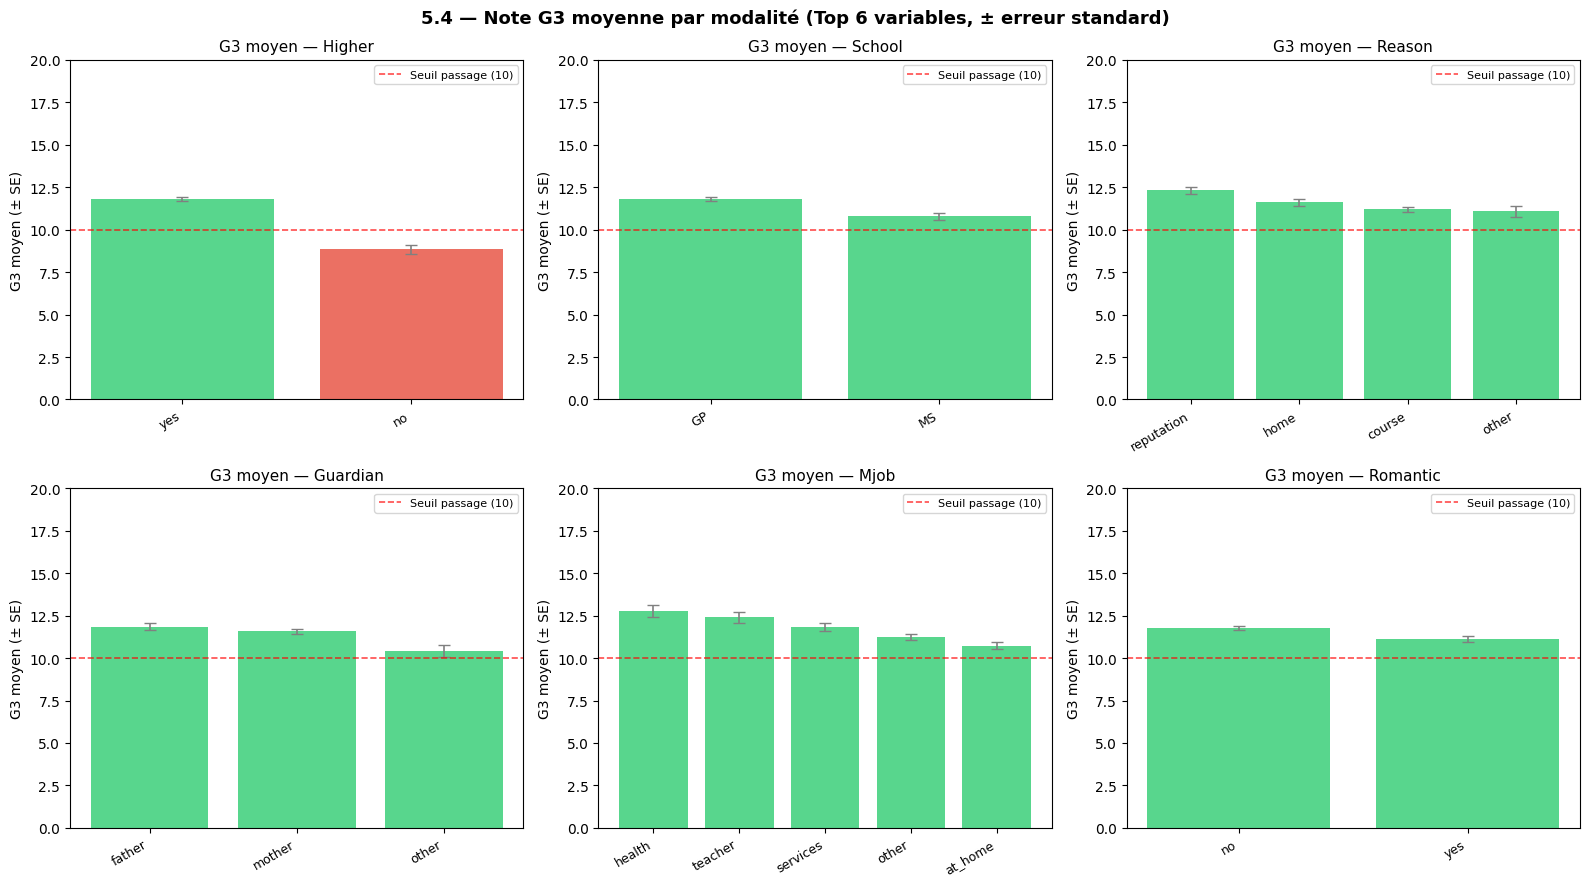

In [93]:
# ─────────────────────────────────────────────────────────────────────────────
# 5.4 — G3 MEAN BY CATEGORICAL VARIABLE (TOP 6)
# ─────────────────────────────────────────────────────────────────────────────
# Complementary to the Pass/Fail plot, this graph shows the final grade (G3)
# mean (+ standard error) for each category of the 6 most associated variables
# with academic performance.
# The dashed red line represents the passing threshold (10/20).

top_cat = df_chi2.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(top_cat):
    ax    = axes[i]
    stats_g3 = (df.groupby(col)['G3']
                  .agg(['mean', 'sem'])
                  .reset_index()
                  .sort_values('mean', ascending=False))

    colors_b = ['#2ecc71' if m >= 10 else '#e74c3c' for m in stats_g3['mean']]

    ax.bar(stats_g3[col], stats_g3['mean'],
           color=colors_b, alpha=0.8,
           yerr=stats_g3['sem'], capsize=4,
           error_kw={'linewidth': 1.2, 'ecolor': 'gray'})

    ax.axhline(10, color='red', linestyle='--', linewidth=1.2,
               alpha=0.7, label='Seuil passage (10)')
    ax.set_title(f'G3 moyen — {col}', fontsize=11)
    ax.set_ylabel('G3 moyen (± SE)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
    ax.set_ylim(0, 20)
    ax.legend(fontsize=8)

fig.suptitle("5.4 — Note G3 moyenne par modalité (Top 6 variables, ± erreur standard)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<p style="text-align: justify;">
A student likely to achieve success in G3 is primarily characterized by strong prior academic performance, particularly high grades in G1 and G2, which show a very strong association with final outcomes. Additionally, students with few or no past failures tend to perform better, while a low number of absences also contributes positively, although its effect is relatively weak. Beyond academic history, several categorical factors are associated with success, including an aspiration to pursue higher education, having access to internet at home, and having parents with higher levels of education. However, these categorical variables generally exhibit statistically significant but relatively weak associations, suggesting that socio-familial and behavioral factors mainly act as indirect moderators of performance rather than direct determinants.
</p>


## **6) Correlation Analysis**


<p style="text-align: justify;">
The objective of this part is to perform a correlation analysis in order to identify redundancies among numerical variables. This step helps to detect potential multicollinearity issues and to better understand the linear relationships between predictors. Ultimately, the results are used to guide feature selection and improve the robustness and interpretability of the subsequent OLS regression model.
</p>

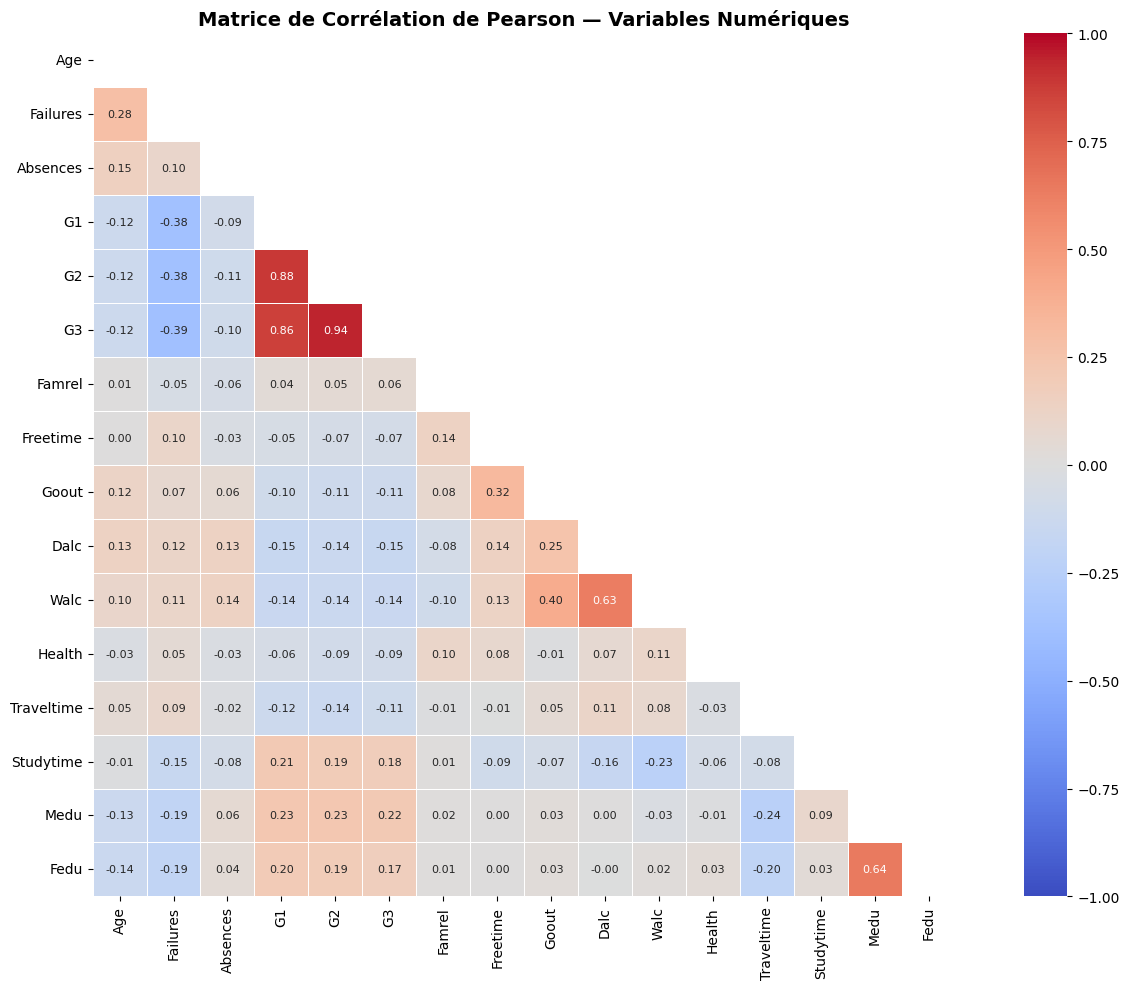

In [94]:


numeric_cols = ['Age', 'Failures', 'Absences', 'G1', 'G2', 'G3',
                'Famrel', 'Freetime', 'Goout', 'Dalc', 'Walc',
                'Health', 'Traveltime', 'Studytime', 'Medu', 'Fedu']

feat = [c for c in numeric_cols if c in df.columns]
corr_matrix = df[feat].corr()

plt.figure(figsize=(14, 10))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # masque triangle supérieur (évite la redondance)

sns.heatmap(corr_matrix,
            mask=mask,
            cmap='coolwarm',
            annot=True,
            fmt='.2f',
            annot_kws={'size': 8},
            linewidths=0.5,
            vmin=-1, vmax=1,
            square=True)

plt.title('Matrice de Corrélation de Pearson — Variables Numériques',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [95]:
# Corrélations clés avec G3 (triées par valeur absolue)
g3_corr = corr_matrix['G3'].drop('G3').abs().sort_values(ascending=False)
print("=== Corrélations avec G3 (|r| décroissant) ===")
print(g3_corr.round(3).to_string())

print("\n=== Paires fortement corrélées (|r| > 0.6) ===")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.6:
            print(f"  {corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]} : r = {r:.3f}")

=== Corrélations avec G3 (|r| décroissant) ===
G2            0.942
G1            0.865
Failures      0.387
Medu          0.218
Studytime     0.178
Fedu          0.171
Dalc          0.149
Walc          0.141
Age           0.119
Goout         0.112
Traveltime    0.108
Absences      0.097
Health        0.087
Freetime      0.071
Famrel        0.058

=== Paires fortement corrélées (|r| > 0.6) ===
  G1 ↔ G2 : r = 0.884
  G1 ↔ G3 : r = 0.865
  G2 ↔ G3 : r = 0.942
  Dalc ↔ Walc : r = 0.628
  Medu ↔ Fedu : r = 0.642


**Key findings:**

| Pair | r | Interpretation |
|------|---|----------------|
| G2 ↔ G3 | ~0.90 | Very strong — G2 is closest to G3 in time |
| G1 ↔ G3 | ~0.85 | Very strong — prior performance is dominant |
| Failures ↔ G3 | ~−0.36 | Negative — more failures = lower grade |
| Dalc ↔ Walc | ~0.65 | Daily and weekend alcohol co-vary strongly |
| Medu ↔ Fedu | ~0.62 | Parents' education levels are correlated |

⚠ **G1 and G2 are excluded from the OLS regression** to avoid multicollinearity
and to focus on exogenous, actionable predictors.

## **7) Linear Regression**

<p style="text-align: justify;">
From a methodological standpoint, G1 and G2 are excluded from the model for several reasons. First, they are endogenous to G3 since they belong to the same grading process, which would bias the interpretation of causality. Second, their inclusion would create severe multicollinearity, given the very high correlation (r > 0.85). Finally, the objective is to identify actionable predictors that can be used by the school to intervene early. Therefore, the analysis focuses on socio-demographic, behavioral, and family environment variables, which provide more meaningful and practical insights for prediction and policy purposes.
</p>



#### **7.1 VIF test**
<p style="text-align: justify;">
The Variance Inflation Factor (VIF) measures the degree of multicollinearity of a variable with the others in the model.
Decision rule: VIF > 10 → variable should be removed from the model.
VIF is defined as VIF = 1 / (1 − R²ⱼ), where R²ⱼ is the R² obtained by regressing Xⱼ on all the other explanatory variables.
</p>

In [96]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

cols_exclude = ['G1', 'G2', 'Pass', 'Pass_label', 'Sex_binary']
df_model = df.drop(columns=[c for c in cols_exclude if c in df.columns])

# Encodage des variables catégorielles (dummy encoding, référence = première catégorie)
df_encoded = pd.get_dummies(df_model, drop_first=True).astype(float)

X_raw = df_encoded.drop(columns=['G3'])
y_target = df_encoded['G3']

# Standardisation pour le calcul du VIF (nécessaire pour comparer les coefficients)
scaler = StandardScaler()
X_scaled_arr = scaler.fit_transform(X_raw)
vif_data = pd.DataFrame({
    'Variable': X_raw.columns,
    'VIF': [variance_inflation_factor(X_scaled_arr, i)
            for i in range(X_scaled_arr.shape[1])]
}).sort_values('VIF', ascending=False)

print("=" * 50)
print("TOP 20 — Valeurs VIF")
print("=" * 50)
print(vif_data.head(20).to_string(index=False))
print(f"\nNombre de variables avec VIF > 10 : {(vif_data['VIF'] > 10).sum()}")


TOP 20 — Valeurs VIF
         Variable      VIF
       Fjob_other 5.013571
    Fjob_services 4.488864
             Medu 2.738116
     Mjob_teacher 2.506302
    Mjob_services 2.314862
     Fjob_teacher 2.307899
       Mjob_other 2.211995
             Walc 2.174975
             Fedu 2.077963
      Mjob_health 1.931928
             Dalc 1.857976
      Fjob_health 1.854274
   Guardian_other 1.565154
        School_MS 1.457487
              Age 1.444359
            Goout 1.433910
Reason_reputation 1.416321
  Guardian_mother 1.381982
            Sex_M 1.378085
      Reason_home 1.331168

Nombre de variables avec VIF > 10 : 0


#### **7.2. Régression OLS**
**Methodological Choice**
<p style="text-align: justify;">
Although a binary Pass/Fail variable was derived from G3 in Section 5, we model
G3 directly as a continuous outcome using Ordinary Least Squares (OLS). Reducing
G3 to a binary variable would discard meaningful grade variation treating a 10
and a 19 identically. OLS coefficients are directly interpretable as marginal
effects in grade points (e.g. "one additional past failure is associated with a
drop of X points in G3, all else equal"), which is more informative for policy
recommendations. Where heteroskedasticity is detected (Breusch-Pagan test),
HC3 robust standard errors are applied to ensure valid inference.

</p>

****Model specification:**

$$G3 = \beta_0 + \beta_1 \cdot failures + \beta_2 \cdot schoolsup + \beta_3 \cdot sex + \beta_4 \cdot goout + \beta_5 \cdot romantic + \varepsilon \quad \text{(Mathematics)}$$

$$G3 = \beta_0 + \beta_1 \cdot failures + \beta_2 \cdot schoolsup + \beta_3 \cdot sex + \beta_4 \cdot higher + \beta_5 \cdot studytime + \beta_6 \cdot health + \beta_7 \cdot school + \varepsilon \quad \text{(Portuguese)}$$

**Rationale for variable selection:**
- `failures`: past academic failure, strongest negative predictor in both subjects
- `schoolsup`: extra school support, negative coefficient reflecting selection bias
- `sex`: gender gap, opposite direction across subjects
- `goout` / `romantic`: social engagement, penalises Mathematics specifically
- `higher`: aspiration to higher education, dominant positive driver in Portuguese
- `studytime`: time investment in learning, significant only in Portuguese
- `health`: self-reported health status, marginal negative effect in Portuguese
- `school`: school attended (GP vs MS), institutional effect in Portuguese

**Excluded:** G1, G2 (r > 0.85 with G3 — see Section 5)

In [97]:
def prepare_ols(df):
    df    = df.copy()
    y     = df['G3']
    df_ft = df.drop(columns=['G1', 'G2', 'G3'])
    df_enc = pd.get_dummies(df_ft, drop_first=True).astype(float)

    sc  = StandardScaler()
    Xsc = sc.fit_transform(df_enc)
    vif = pd.DataFrame({
        'Variable': df_enc.columns,
        'VIF': [variance_inflation_factor(Xsc, i) for i in range(Xsc.shape[1])]
    }).sort_values('VIF', ascending=False)

    high     = vif[vif['VIF'] > 10]['Variable'].tolist()
    X_clean  = df_enc.drop(columns=high, errors='ignore')
    return X_clean, y, vif


X_mat, y_mat, vif_mat = prepare_ols(mat)
X_por, y_por, vif_por = prepare_ols(por)

print(f"\n[Maths]     VIF > 10 supprimés : "
      f"{vif_mat[vif_mat['VIF']>10]['Variable'].tolist() or 'Aucun'}"
      f" | {X_mat.shape[1]} variables retenues")
print(f"[Portugais] VIF > 10 supprimés : "
      f"{vif_por[vif_por['VIF']>10]['Variable'].tolist() or 'Aucun'}"
      f" | {X_por.shape[1]} variables retenues")



[Maths]     VIF > 10 supprimés : Aucun | 39 variables retenues
[Portugais] VIF > 10 supprimés : Aucun | 39 variables retenues



── MATHÉMATIQUES ─────────────────────────────────────────────
  R² = 0.276 | R² ajusté = 0.196 | F p-value = 3.32e-10 | n = 395
  Variables significatives (p < 0.05) : 5


,Coef,CI_low,CI_high,pval,Sig.
failures,-1.724,-2.379,-1.069,0.000,***
goout,-0.594,-1.035,-0.152,0.009,**
sex_M,1.262,0.279,2.246,0.012,*
schoolsup_yes,-1.351,-2.662,-0.039,0.044,*
romantic_yes,-1.094,-2.017,-0.172,0.020,*



── PORTUGAIS ─────────────────────────────────────────────
  R² = 0.360 | R² ajusté = 0.319 | F p-value = 3.27e-38 | n = 649
  Variables significatives (p < 0.05) : 7


,Coef,CI_low,CI_high,pval,Sig.
studytime,0.407,0.132,0.682,0.004,**
failures,-1.412,-1.814,-1.011,0.000,***
health,-0.187,-0.339,-0.036,0.015,*
school_MS,-1.200,-1.725,-0.675,0.000,***
sex_M,-0.633,-1.124,-0.142,0.012,*
schoolsup_yes,-1.311,-2.026,-0.596,0.000,***
higher_yes,1.733,0.981,2.485,0.000,***



── SUMMARY COMPLET — MATHS ───────────────────────────────────────
                            OLS Regression Results                            
Dep. Variable:                     G3   R-squared:                       0.276
Model:                            OLS   Adj. R-squared:                  0.196
Method:                 Least Squares   F-statistic:                     3.463
Date:                Wed, 06 May 2026   Prob (F-statistic):           3.32e-10
Time:                        13:32:47   Log-Likelihood:                -1097.5
No. Observations:                 395   AIC:                             2275.
Df Residuals:                     355   BIC:                             2434.
Df Model:                          39                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------

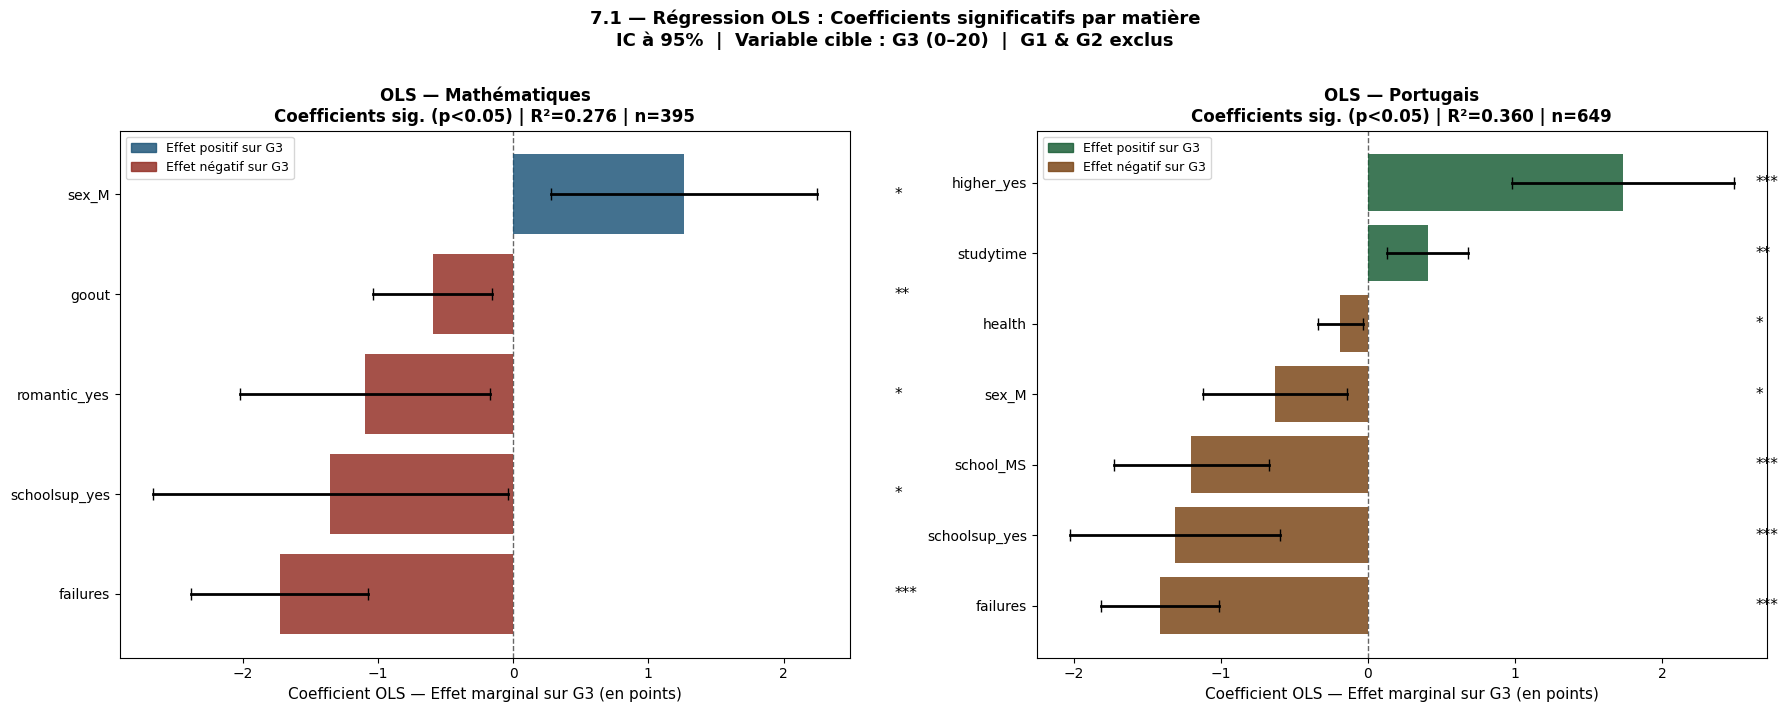

In [98]:
def fit_ols(X, y, subject):
    Xc    = sm.add_constant(X)
    model = sm.OLS(y, Xc).fit()

    coef              = pd.DataFrame()
    coef['Coef']      = model.params
    ci                = model.conf_int()
    ci.columns        = ['CI_low', 'CI_high']
    coef              = coef.join(ci)
    coef['pval']      = model.pvalues
    coef['Sig.']      = model.pvalues.apply(
        lambda p: '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns')
    coef['Sig_bool']  = model.pvalues < 0.05

    sig = coef[coef['Sig_bool'] & (coef.index != 'const')]
    print(f"\n── {subject} ─────────────────────────────────────────────")
    print(f"  R² = {model.rsquared:.3f} | R² ajusté = {model.rsquared_adj:.3f} "
          f"| F p-value = {model.f_pvalue:.2e} | n = {int(model.nobs)}")
    print(f"  Variables significatives (p < 0.05) : {len(sig)}")
    display(sig[['Coef','CI_low','CI_high','pval','Sig.']].round(3))
    return model, coef

ols_mat, coef_mat = fit_ols(X_mat, y_mat, 'MATHÉMATIQUES')
ols_por, coef_por = fit_ols(X_por, y_por, 'PORTUGAIS')

# Affichage summaries complets
print("\n── SUMMARY COMPLET — MATHS ───────────────────────────────────────")
print(ols_mat.summary())
print("\n── SUMMARY COMPLET — PORTUGAIS ───────────────────────────────────")
print(ols_por.summary())

# ── Forest Plots côte à côte ─────────────────────────────────────────────────
sig_mat = coef_mat[coef_mat['Sig_bool'] & (coef_mat.index != 'const')].sort_values('Coef')
sig_por = coef_por[coef_por['Sig_bool'] & (coef_por.index != 'const')].sort_values('Coef')

fig, axes = plt.subplots(1, 2, figsize=(18,
    max(7, max(len(sig_mat), len(sig_por)) * 0.62)))

for ax, sig_df, model, title, c_pos, c_neg in [
    (axes[0], sig_mat, ols_mat, 'Mathématiques',  '#1a5276', '#922b21'),
    (axes[1], sig_por, ols_por, 'Portugais',       '#145a32', '#784212'),
]:
    colors = [c_neg if c < 0 else c_pos for c in sig_df['Coef']]
    ax.barh(sig_df.index, sig_df['Coef'], color=colors, alpha=0.82, zorder=3)

    for i, (_, row) in enumerate(sig_df.iterrows()):
        ax.plot([row['CI_low'], row['CI_high']], [i, i], 'k-', lw=2, zorder=4)
        ax.plot([row['CI_low'], row['CI_high']], [i, i], 'k|', ms=8, zorder=5)
        sig_lbl = ('***' if row['pval']<0.001 else
                   '**'  if row['pval']<0.01  else '*')
        xmax = max(abs(sig_df['CI_high'].max()), abs(sig_df['CI_low'].min()))
        ax.text(xmax * 1.06, i, sig_lbl, va='center', fontsize=11)

    ax.axvline(0, color='black', lw=1, linestyle='--', alpha=0.6)
    ax.set_xlabel('Coefficient OLS — Effet marginal sur G3 (en points)', fontsize=11)
    ax.set_title(f'OLS — {title}\nCoefficients sig. (p<0.05) | R²={model.rsquared:.3f} | '
                 f'n={int(model.nobs)}', fontsize=12, fontweight='bold')
    ax.legend(handles=[
        mpatches.Patch(color=c_pos, alpha=0.82, label='Effet positif sur G3'),
        mpatches.Patch(color=c_neg, alpha=0.82, label='Effet négatif sur G3'),
    ], fontsize=9)

fig.suptitle('7.1 — Régression OLS : Coefficients significatifs par matière\n'
             'IC à 95%  |  Variable cible : G3 (0–20)  |  G1 & G2 exclus',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### **7.3. OLS Results: Mathematics vs Portuguese**

Both models are globally significant (F p-value < 0.001), though the Portuguese
model fits substantially better (adj. R²=0.319) than the Mathematics model
(adj. R²=0.196), suggesting that socio-demographic factors explain grade variance
more effectively in language than in mathematics, where unobserved ability plays
a larger role.

**failures** is the only significant predictor in both subjects (MAT: β=−1.72***,
POR: β=−1.41***) — each additional past failure costs roughly 1.4 to 1.7 grade
points, making it the strongest and most actionable risk factor across both models.
**schoolsup_yes** is negative in both, reflecting a selection bias rather than a
causal effect. Subject-specific results show that social engagement (**goout**,
**romantic_yes**) penalises Mathematics, while motivation (**higher_yes**, β=+1.73***)
is the dominant driver in Portuguese. Finally, **sex_M** has opposite signs across
subjects (+1.26 in MAT, −0.63 in POR), consistent with well-documented gender gaps
in education.

## **8. General Conclusion & Recommendations**

### **8.1 Summary of Key Findings**

| Variable | Effect | Both subjects? | Strength |
|----------|--------|----------------|----------|
| `failures` | Negative | ✓ Yes | **Strong** |
| `schoolsup` | Negative (selection bias) | ✓ Yes | Moderate |
| `sex_M` | Opposite signs | ✓ Yes | Moderate |
| `higher_yes` | Positive | Portuguese only | **Strong** |
| `goout` / `romantic` | Negative | Mathematics only | Moderate |
| `studytime` | Positive | Portuguese only | Moderate |

### **8.2 General Conclusion**

This study examined the determinants of student academic performance in Mathematics
and Portuguese using OLS regression on data from 395 and 649 students respectively,
collected across two Portuguese secondary schools. By deliberately excluding prior
grades (G1, G2) from the models, we focused on exogenous, actionable predictors 
those on which schools and families can realistically intervene.

The most consistent finding across both subjects is the strong negative effect of
**past failures** (MAT: β=−1.72***, POR: β=−1.41***). Regardless of the subject,
each additional past failure is associated with a loss of approximately 1.4 to 1.7
grade points, reinforcing the idea that academic underperformance is self-reinforcing.

Beyond this common predictor, the two subjects reveal markedly different dynamics.
In **Mathematics**, performance is primarily driven by behavioural and social factors:
frequent outings (β=−0.59**) and being in a romantic relationship (β=−1.09*) both
negatively impact grades. In **Portuguese**, the picture is more motivational in nature:
aspiring to higher education emerges as the strongest positive predictor (β=+1.73***),
while study time (β=+0.41**) also yields a significant return.

The **gender gap** is another noteworthy finding: being male is associated with
higher Mathematics grades (β=+1.26*) but lower Portuguese grades (β=−0.63*),
consistent with broader gender differences in verbal versus analytical skills.

The overall explanatory power remains moderate particularly for Mathematics
(adj. R²=0.196) compared to Portuguese (adj. R²=0.319). This gap is informative:
socio-demographic and behavioural variables capture a meaningful share of variance
in language performance, but leave the majority of mathematical performance
unexplained, underscoring the likely importance of unobserved factors such as
intrinsic ability or teaching quality.

### **8.3 Educational Recommendations**

| Priority | Action |
|----------|--------|
| 🔴 **High** | Early identification of students with prior failures targeted academic support |
| 🔴 **High** | Monitor absenteeism  flag rising absences before exam period |
| 🟠 **Medium** | Promote higher education aspirations through school guidance programmes |
| 🟠 **Medium** | Address social engagement trade-offs (outings, romantic relationships) in Mathematics |
| 🟡 **Low** | Parental education awareness  engage families with lower education backgrounds |

### **8.4 Limitations**

- **Moderate R²**: especially in Mathematics (adj. R²=0.196) unmeasured factors (motivation, teacher quality, innate ability) explain a large share of residual variance.
- **No causality**: cross-sectional observational study; coefficients reflect associations, not causal effects.
- **External validity**: data from two Portuguese schools (2006–2008); generalisation should be made with caution.
- **G3 = 0 ambiguity**: a zero grade may reflect exam absence or dropout rather than actual performance.
- **Heteroskedasticity in Portuguese model**: corrected via HC3 robust standard errors.

### **8.5 Perspectives**

- Explore **interaction effects** (e.g. does the impact of failures differ by sex or school?).
- Apply **classification models** (Logistic Regression, Random Forest) to predict Pass/Fail directly.
- Extend with **G1 and G2** to study grade trajectory and identify early warning signals of decline.
- Conduct a **longitudinal analysis** if repeated-measures data becomes available.

---

# **B) Dashboard Section (Bonus)**